In [1]:
PROG_NAME = "Prunability0"

## Packages

In [2]:
!pip install tensorboard

In [3]:
from PIL import Image, ImageOps, ImageFilter
from torch import nn, optim
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

from torch.utils.tensorboard import SummaryWriter

import logging
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from collections import defaultdict
from google.colab import drive
import zipfile
import random
from sklearn.decomposition import PCA
import torchvision.models as models


import cv2
import plotly.graph_objects as go

In [4]:
DEVICE =  'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def torch_to_numpy(a):
    """
    Converts a torch tensor to a numpy array.
    """
    return a.detach().cpu().numpy()

## Data loader

In [7]:
def extract_zip(src_path, targ_path):
   """
   Extracts a zip file to a target directory.
   Input:
   src_path: str (path to zip file)
   targ_path: str (path to target directory)

   Output:
   No output.
   """
   with zipfile.ZipFile(src_path,"r") as zip_ref:
        zip_ref.extractall(targ_path)

In [8]:
class Transform:
    """
    Image Augmentaion Utilities
    """
    def __init__(
        self,
        reshaped_size = 64,
        normalize_mean=[0.485, 0.456, 0.406],
        normalize_std=[0.229, 0.224, 0.225]
    ):
        """
        The constructor creates a torch.transforms.Compose object. This object has sequential steps for the augmneations
        """
        self.transform = transforms.Compose([
            transforms.Resize(reshaped_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=normalize_mean, std=normalize_std)
        ])

    def __call__(self, x):
        """
        Tranforms x -> xt
        """
        xt = self.transform(x)
        return xt

In [9]:
def get_loaders(TAR_PATH,
                batch_size=32,
                reshaped_size=64,
                normalize_mean=[0.485, 0.456, 0.406],
                normalize_std=[0.229, 0.224, 0.225]):

    """
    It is wrapper function for getting train and test loaders.
    In each iteration it will yield a list of two tensors (X and Y)
    Shape of X : (batch_size, 3, reshaped_size, reshaped_size)
    Shape of Y : (batch_size)
    Note: X and Y are not type casted to device and type.

    Inputs:
      1. TAR_PATH : The parent directory that contains two sub-directories, train and test.
      2. batch_size
      3. reshaped_size: Input's Height / Width considering Height = Width
      4. normalize_mean
      5. normalize_std

    Output:
      1. train_dataset_loader
      2. test_dataset_loader
    """
    custom_transformer = Transform(
        reshaped_size=reshaped_size,
        normalize_mean=normalize_mean,
        normalize_std=normalize_std
    )

    train_dataset = torchvision.datasets.ImageFolder(f"{TAR_PATH}/train", custom_transformer)
    test_dataset = torchvision.datasets.ImageFolder(f"{TAR_PATH}/test", custom_transformer)
    train_dataset_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    return train_dataset_loader, test_dataset_loader

In [10]:
SRC_PATH = "/content/drive/MyDrive/ug26_3/ssl_ug4/datasets/cifar10.zip"
TAR_PATH = "./cifar10/"
extract_zip(SRC_PATH, TAR_PATH)

In [11]:
HEIGHT, WIDTH = 64,64
BATCH_SIZE = 64

# Dataloaders for train and test dataset respectively
TRAIN_DATASET_LOADER, TEST_DATASET_LOADER = get_loaders(
    TAR_PATH,
    batch_size=BATCH_SIZE,
    reshaped_size=HEIGHT,
    normalize_mean=[0.485, 0.456, 0.406],
    normalize_std=[0.229, 0.224, 0.225]
)

TOTAL_TRAIN_SAMPLES = len(TRAIN_DATASET_LOADER.dataset) # Total number of samples in train dataset
TOTAL_VAL_SAMPLES = len(TEST_DATASET_LOADER.dataset) # Total number of samples in val dataset
NUM_LABS = len(TRAIN_DATASET_LOADER.dataset.classes) # Total number of classes

## Model

In [12]:
class SampleMlpModel(nn.Module):
  """
  4 layer MLP Model with Batch Normalization
  """
  def __init__(self, num_classes=10):
    super(SampleMlpModel, self).__init__()
    self.fc1 = nn.Linear(32 * 32 * 3, 128)
    self.bn1 = nn.BatchNorm1d(128)
    self.fc2 = nn.Linear(128, 64)
    self.bn2 = nn.BatchNorm1d(64)
    self.fc3 = nn.Linear(64, 32)
    self.bn3 = nn.BatchNorm1d(32)
    self.fc4 = nn.Linear(32, num_classes)
    # self.drop = nn.Dropout(0.5)
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = F.relu(self.bn1(self.fc1(x)))
    x = F.relu(self.bn2(self.fc2(x)))
    x = F.relu(self.bn3(self.fc3(x)))
    x = self.fc4(x)
    x = self.softmax(x)
    return x

In [13]:
class SampleCnnModel(nn.Module):
    def __init__(self, num_classes=10):
        super(SampleCnnModel, self).__init__()

        # First Conv Block
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.drop1 = nn.Dropout(0.3)

        # Second Conv Block
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.drop2 = nn.Dropout(0.5)

        # Third Conv Block
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)
        self.drop3 = nn.Dropout(0.5)

        # The fully connected layers (flatten first)
        # You need to compute the flattened size based on input image dimensions
        self.fc1 = nn.Linear(128 * (HEIGHT // 8) * (WIDTH // 8), 128)  # Adjust based on pooling
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.drop_fc1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc1(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [14]:
def load_model(num_lab, model_class, path=None):
  """
  Loads a pre-trained model if a path is provided, otherwise creates a new model.

  Args:
      num_lab (int): The number of labels/classes in the dataset.
      model_class (nn.Module): The class of the model to be loaded or created.
      path (str, optional): The path to the pre-trained model file. Defaults to None.

  Returns:
      nn.Module: The loaded or newly created model.
  """
  # Create an instance of the model_class
  model = model_class(num_classes=num_lab)

  # If a path is provided and the file exists, load the pre-trained weights
  if path and os.path.exists(path):
      # Explicitly map the loaded tensors to CPU
      model.load_state_dict(torch.load(path, map_location=torch.device(DEVICE)))
      print(f"Model loaded from {path}")
  else:
      print(f"Model not found at {path}")  # Print a message if the model file is not found

  # Move the model to the specified device (e.g., CPU or GPU)
  model = model.to(DEVICE)
  return model

def save_model(model, path):
  """
  Saves the model's state dictionary to the specified path.

  Args:
      model (nn.Module): The model to be saved.
      path (str): The path to save the model file.
  """
  # Save the model's state dictionary
  torch.save(model.state_dict(), path)

# Warm Area

In [15]:
!ls /content/drive/MyDrive/MyEXP25/prune/results/

aug_effect_cnn_cifar_0.pth  aug_effect_mlp_mnist_1.pth
aug_effect_mlp_mnist_0.pth


In [16]:
# aug_effect_cnn_cifar_0.pth
# aug_effect_mlp_mnist_1.pth
# aug_effect_mlp_mnist_0.pth

LOAD_MODEL_PATH = "/content/drive/MyDrive/MyEXP25/prune/results/aug_effect_cnn_cifar_0.pth"

In [17]:
# SAMPLE_MLP_MODEL = load_model(
#     num_lab=NUM_LABS,
#     model_class=SampleMlpModel,
#     path=LOAD_MODEL_PATH
# )

SAMPLE_CNN_MODEL = load_model(
    num_lab=NUM_LABS,
    model_class=SampleCnnModel,
    path=LOAD_MODEL_PATH
)

Model loaded from /content/drive/MyDrive/MyEXP25/prune/results/aug_effect_cnn_cifar_0.pth


# Infering and Visulalization

In [81]:
# ===============================
# 📦 SUPPORTING FUNCTIONS
# ===============================

def torch_to_numpy(a):
    """Converts a torch tensor to a numpy array."""
    return a.detach().cpu().numpy()


def get_intermediate_outputs(model, x):
    """Run forward pass and return dict of intermediate layer outputs."""
    outputs = {}
    hooks = []

    def save_output(name):
        def hook(module, input, output):
            outputs[name] = output.detach()
        return hook

    for name, module in model.named_modules():
        if len(list(module.children())) == 0:
            hooks.append(module.register_forward_hook(save_output(name)))

    _ = model(x)
    for h in hooks:
        h.remove()

    return outputs


def augment_batch(x):
    """Apply augmentations (rotation + color jitter) to a batch."""
    rotation = transforms.RandomRotation(degrees=20)
    color_jitter = transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.2)
    augmentations = transforms.Compose([rotation, color_jitter])
    aug_x = torch.stack([augmentations(img) for img in x])
    return aug_x


def multiple_augmentations(batch, salting_round=5):
    """Generate multiple augmentations for a batch."""
    x, y = batch
    aug_x_list, aug_y_list = [], []
    for _ in range(salting_round):
        aug_x = augment_batch(x)
        aug_x_list.append(aug_x)
        aug_y_list.append(y)
    return torch.cat(aug_x_list, dim=0), torch.cat(aug_y_list, dim=0)


def plot_3d_slices(matrix, title="3D Slice Plot", xlabel="X", ylabel="Y", zlabel="Z"):
    """3D interactive visualization of stacked 2D slices."""
    assert matrix.ndim == 3, "Input must be a 3D numpy array"

    n_slices, ny, nx = matrix.shape
    fig = go.Figure()
    z_gap = 1.5

    for i in range(n_slices):
        z = np.full((ny, nx), i * z_gap)
        fig.add_surface(
            x=np.arange(nx),
            y=np.arange(ny),
            z=z,
            surfacecolor=matrix[i],
            cmin=np.min(matrix),
            cmax=np.max(matrix),
            colorscale="Viridis",
            showscale=(i == n_slices - 1)
        )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=xlabel,
            yaxis_title=ylabel,
            zaxis_title=zlabel,
            aspectmode="cube",
        ),
        width=800,
        height=800,
    )
    fig.show()


def activation(x, scale=False, temp=1.0):
    """Sigmoid-like activation or scaled normalization."""
    if scale:
        return (x - np.min(x)) / (np.max(x) - np.min(x))
    return 1. / (1. + np.exp(-x / temp))


def get_layer_weights_and_grads(model, x, y_true, loss_fn=None):
    """Run forward+backward pass and return dicts of layer weights and grads."""
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()

    model.train()
    model.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y_true)
    loss.backward()

    weights, grads = {}, {}
    for name, module in model.named_modules():
        if hasattr(module, "weight") and module.weight is not None:
            weights[name] = module.weight.detach().clone()
            grads[name] = module.weight.grad.detach().clone() if module.weight.grad is not None else None
    return weights, grads

def print_model_layer_names(model):
    """Print the names of all layers in the model."""
    for name, _ in model.named_modules():
        print(name)

In [82]:
# ===============================
# ⚙️ REFACTORED VISUALIZATION FUNCTIONS
# ===============================

def evaluate_batch_accuracy(model, x, y):
    model.eval()
    with torch.no_grad():
        y_pred = model(x.to(DEVICE))
        _, predicted = torch.max(y_pred.data, 1)
        acc = (predicted == y.to(DEVICE)).sum().item() / y.size(0)
    return acc


def get_augmented_batch(batch, salting_round=5):
    x, y = batch
    aug_x_list, aug_y_list = [], []
    for _ in range(salting_round):
        aug_x_list.append(augment_batch(x))
        aug_y_list.append(y)
    return torch.cat(aug_x_list, dim=0), torch.cat(aug_y_list, dim=0)


def visualize_feature_matrix(model, x, layer_name, activation_temp=0.05, num_features=512):
    outputs = get_intermediate_outputs(model, x.to(DEVICE))
    features = activation(torch_to_numpy(outputs[layer_name]) / activation_temp)
    features = np.reshape(features, (features.shape[0], -1))
    feature_index_subset = np.random.choice(features.shape[1], size=min(num_features, features.shape[1]), replace=False)
    plt.figure(figsize=(20, 10))
    plt.imshow(features[:, feature_index_subset])
    plt.xlabel('sampled vector index')
    plt.ylabel('batch')
    plt.title(f"Flattened Features from {layer_name}")
    plt.show()


def visualize_feature_maps(model, x, layer_name, activation_temp=0.4, pixel_clip=100, filter_clip=32, batch_clip=10):
    intermediate_outputs = get_intermediate_outputs(model, x.to(DEVICE))
    feature_stack = torch_to_numpy(intermediate_outputs[layer_name])
    feature_stack = feature_stack.reshape(feature_stack.shape[0], feature_stack.shape[1], -1)
    feature_stack = (feature_stack - np.min(feature_stack)) / (np.max(feature_stack) - np.min(feature_stack))
    feature_stack = activation(feature_stack / activation_temp)
    feature_stack = feature_stack[:batch_clip, :filter_clip, :pixel_clip]
    plot_3d_slices(feature_stack, title=f"3D Features ({layer_name})", xlabel="pixels", ylabel="filters", zlabel="batch")


def collect_weights_and_grads(model, x_batch, y_batch, layer_name):
    model_weights = None
    batch_grads = []

    for i in range(x_batch.shape[0]):
        x, y = x_batch[i:i+1], y_batch[i:i+1]
        x, y = torch.cat([x, x]), torch.cat([y, y])
        layer_weights, layer_grads = get_layer_weights_and_grads(
            model=model,
            x=x.to(DEVICE),
            y_true=y.to(DEVICE),
            loss_fn=None
        )
        model_weights = layer_weights
        batch_grads.append(layer_grads)

    grads_array = [g[layer_name] for g in batch_grads]
    weights = model_weights[layer_name]
    return grads_array, weights


def visualize_gradients_vs_weights(grads_list, weights, layer_name, sample_size=200):
    num_params = grads_list[0].reshape(-1).shape[0]
    sampled_indices = np.random.choice(num_params, size=min(sample_size, num_params), replace=False)

    batch_sampled_grads = np.array([
        torch_to_numpy(g.reshape(-1)[sampled_indices]) for g in grads_list
    ])
    sampled_weights = np.expand_dims(weights.reshape(-1)[sampled_indices].detach().cpu().numpy(), axis=0)

    activated_grads = activation(batch_sampled_grads, scale=True, temp=0.1)
    activated_weights = activation(sampled_weights, scale=True, temp=0.1)

    plt.figure(figsize=(40, 20))
    plt.imshow(activated_grads, cmap='gray')
    plt.xlabel('sampled vector index')
    plt.ylabel('batch')
    plt.title(f"Gradients Heatmap ({layer_name})")
    plt.show()

    plt.figure(figsize=(40, 20))
    plt.imshow(activated_weights, cmap='gray')
    plt.title(f"Weights Heatmap ({layer_name})")
    plt.show()

    plt.figure(figsize=(40, 20))
    for i in range(activated_grads.shape[0]):
        plt.plot(activated_grads[i], alpha=0.5, label='Gradient')
    plt.plot(activated_weights[0], linestyle='--', color='red', linewidth=1, label='Weights')
    plt.legend()
    plt.xlabel('sampled vector index')
    plt.ylabel('activation')
    plt.title(f"Gradients vs Weights ({layer_name})")
    plt.show()

## ===============================
## 🚀 MAIN EXECUTION
## ===============================

In [98]:
# ===============================
# 🧩 INFERENCING & VISUALIZATION
# ===============================

# ==== CONFIGURATION ====
BATCH_CLIP = 4              # Number of images to sample from batch
SALTING_ROUND = 32           # Number of augmentations per image
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL = SAMPLE_CNN_MODEL     # Loaded model
DATA_LOADER = TRAIN_DATASET_LOADER

In [99]:
print_model_layer_names(MODEL)


conv1
bn1
conv2
bn2
pool1
drop1
conv3
bn3
conv4
bn4
pool2
drop2
conv5
bn5
conv6
bn6
pool3
drop3
fc1
bn_fc1
drop_fc1
fc2


In [100]:
# Get sample batch
sample_x, sample_y = next(iter(DATA_LOADER))
print(f"Sample batch shape: {sample_x.shape}, Labels: {sample_y.shape}")


Sample batch shape: torch.Size([64, 3, 64, 64]), Labels: torch.Size([64])


In [101]:
# Create augmented batch
sample_x_augs, sample_y_augs = get_augmented_batch((sample_x[:BATCH_CLIP], sample_y[:BATCH_CLIP]), SALTING_ROUND)
print(f"Augmented batch shape: {sample_x_augs.shape}")



Augmented batch shape: torch.Size([128, 3, 64, 64])


In [102]:
# Evaluate accuracy before augmentations
acc = evaluate_batch_accuracy(MODEL, sample_x, sample_y)
print(f"Base Accuracy: {acc * 100:.2f}%")


Base Accuracy: 96.88%


In [103]:
# Evaluate accuracy after augmentations
aug_acc = evaluate_batch_accuracy(MODEL, sample_x_augs, sample_y_augs)
print(f"Augmented Accuracy: {aug_acc * 100:.2f}%")

Augmented Accuracy: 74.22%


## Preparing the Visualization Params

In [120]:
LAYER_NAMES = ['conv3', 'conv6', 'fc1']
NUM_SAMPLE_GRADS = 256       # Number of parameters to sample for gradient plots

## Visulalzing the Augmented Version

/tmp/ipython-input-1492638592.py:90: RuntimeWarning:

overflow encountered in exp



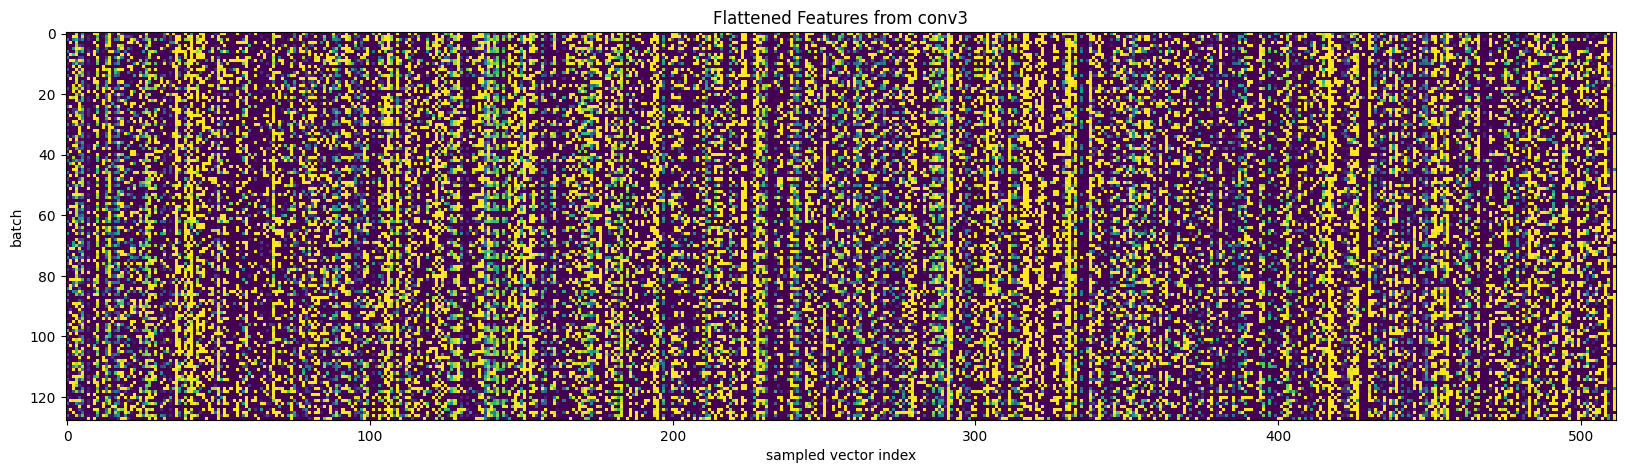

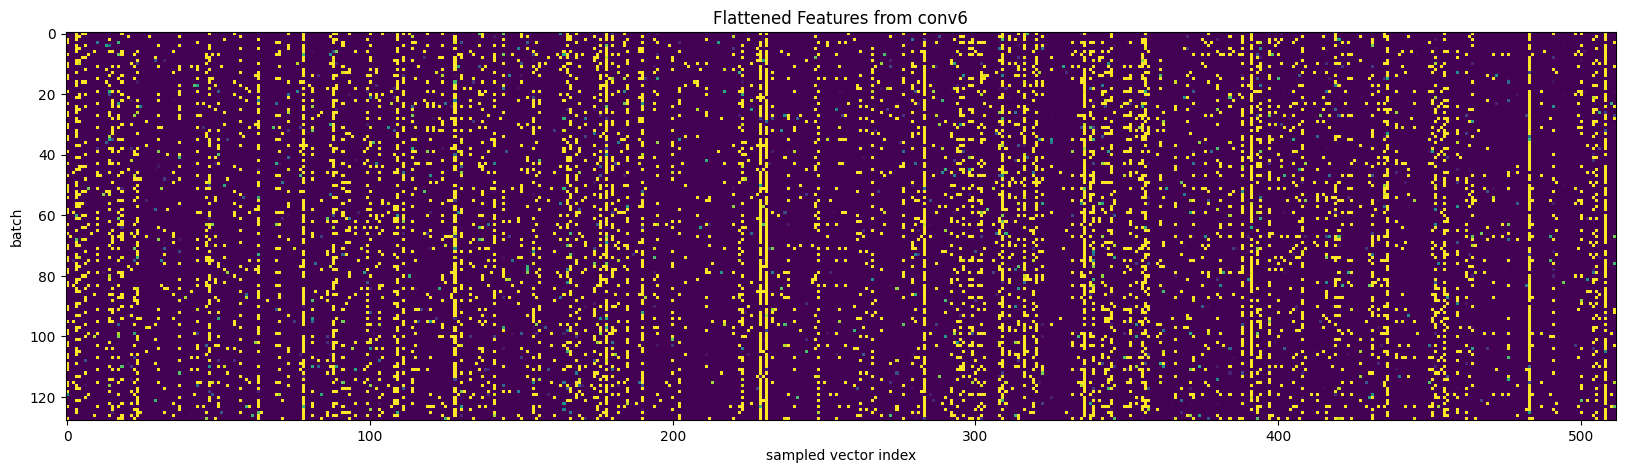

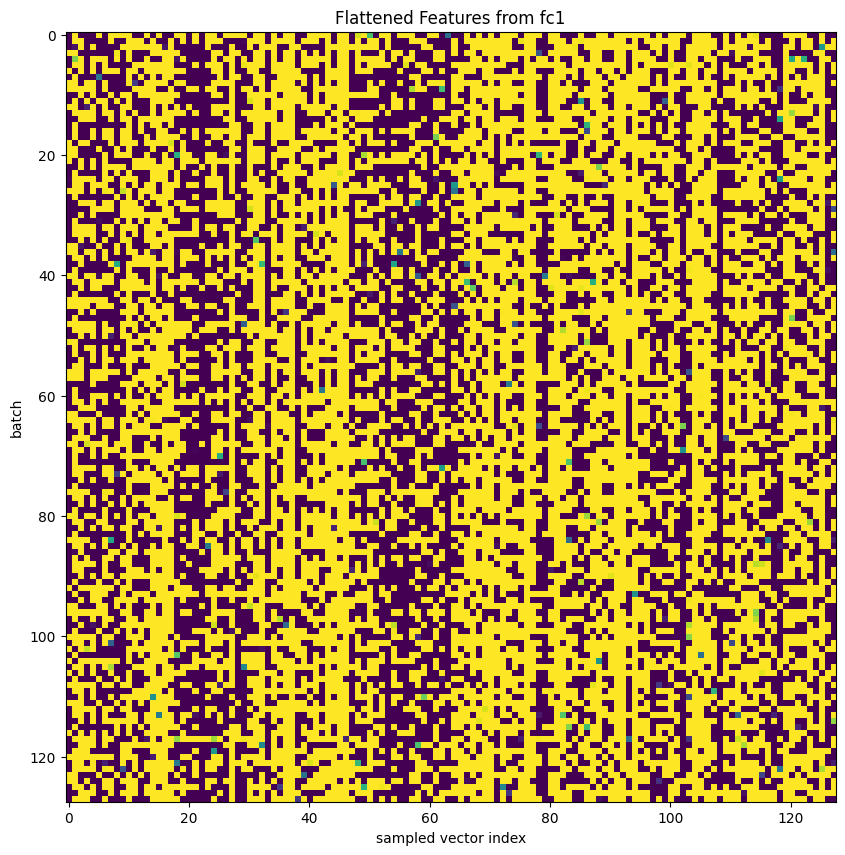

In [121]:
for layer_name in LAYER_NAMES:
  # Visualize intermediate features from 'layer'
  visualize_feature_matrix(MODEL, sample_x_augs, layer_name=layer_name)

In [105]:
# visualize_feature_maps(MODEL, sample_x_augs, layer_name=VIS_LAYER)

In [122]:
grads_weights_augs = {}
for layer_name in LAYER_NAMES:
  grads_list_aug, weights = collect_weights_and_grads(MODEL, sample_x_augs, sample_y_augs, layer_name=layer_name)
  grads_weights_augs[layer_name] = (grads_list_aug, weights)

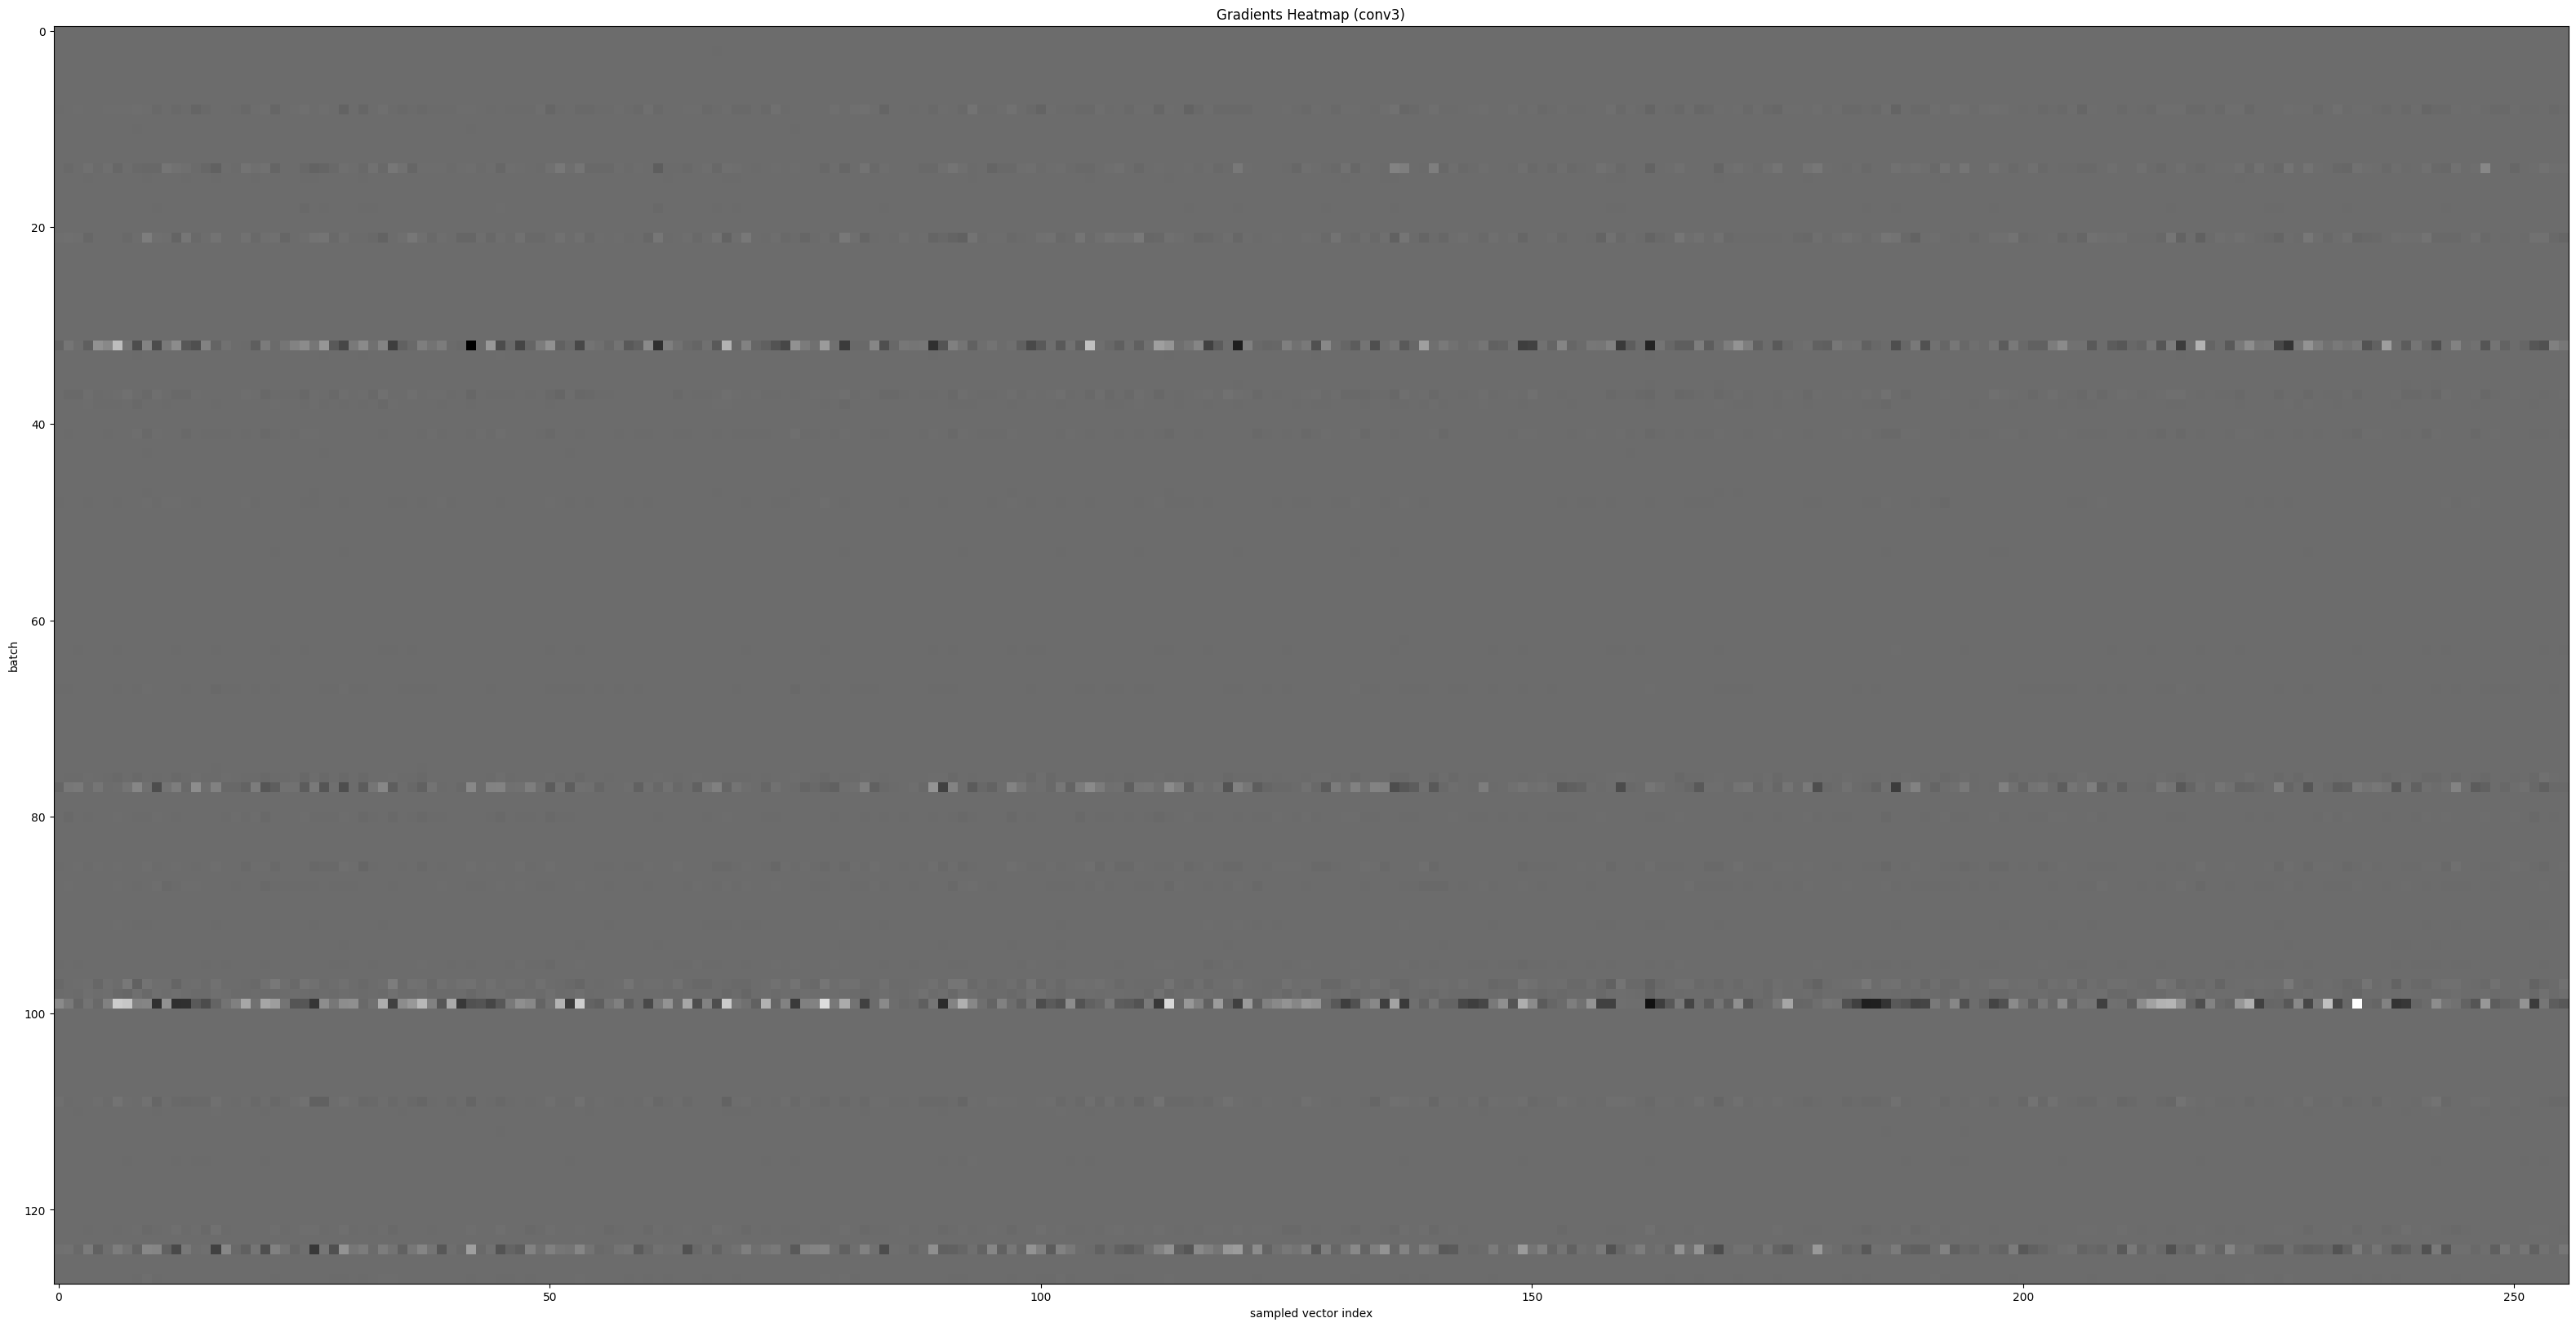

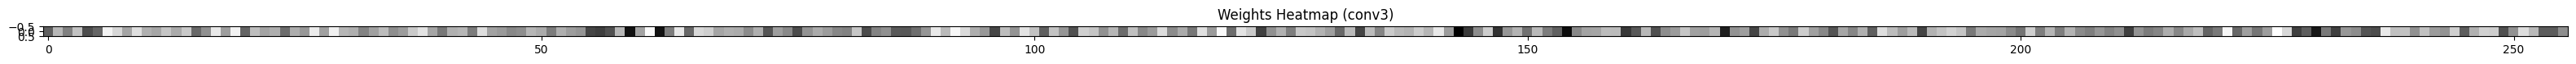

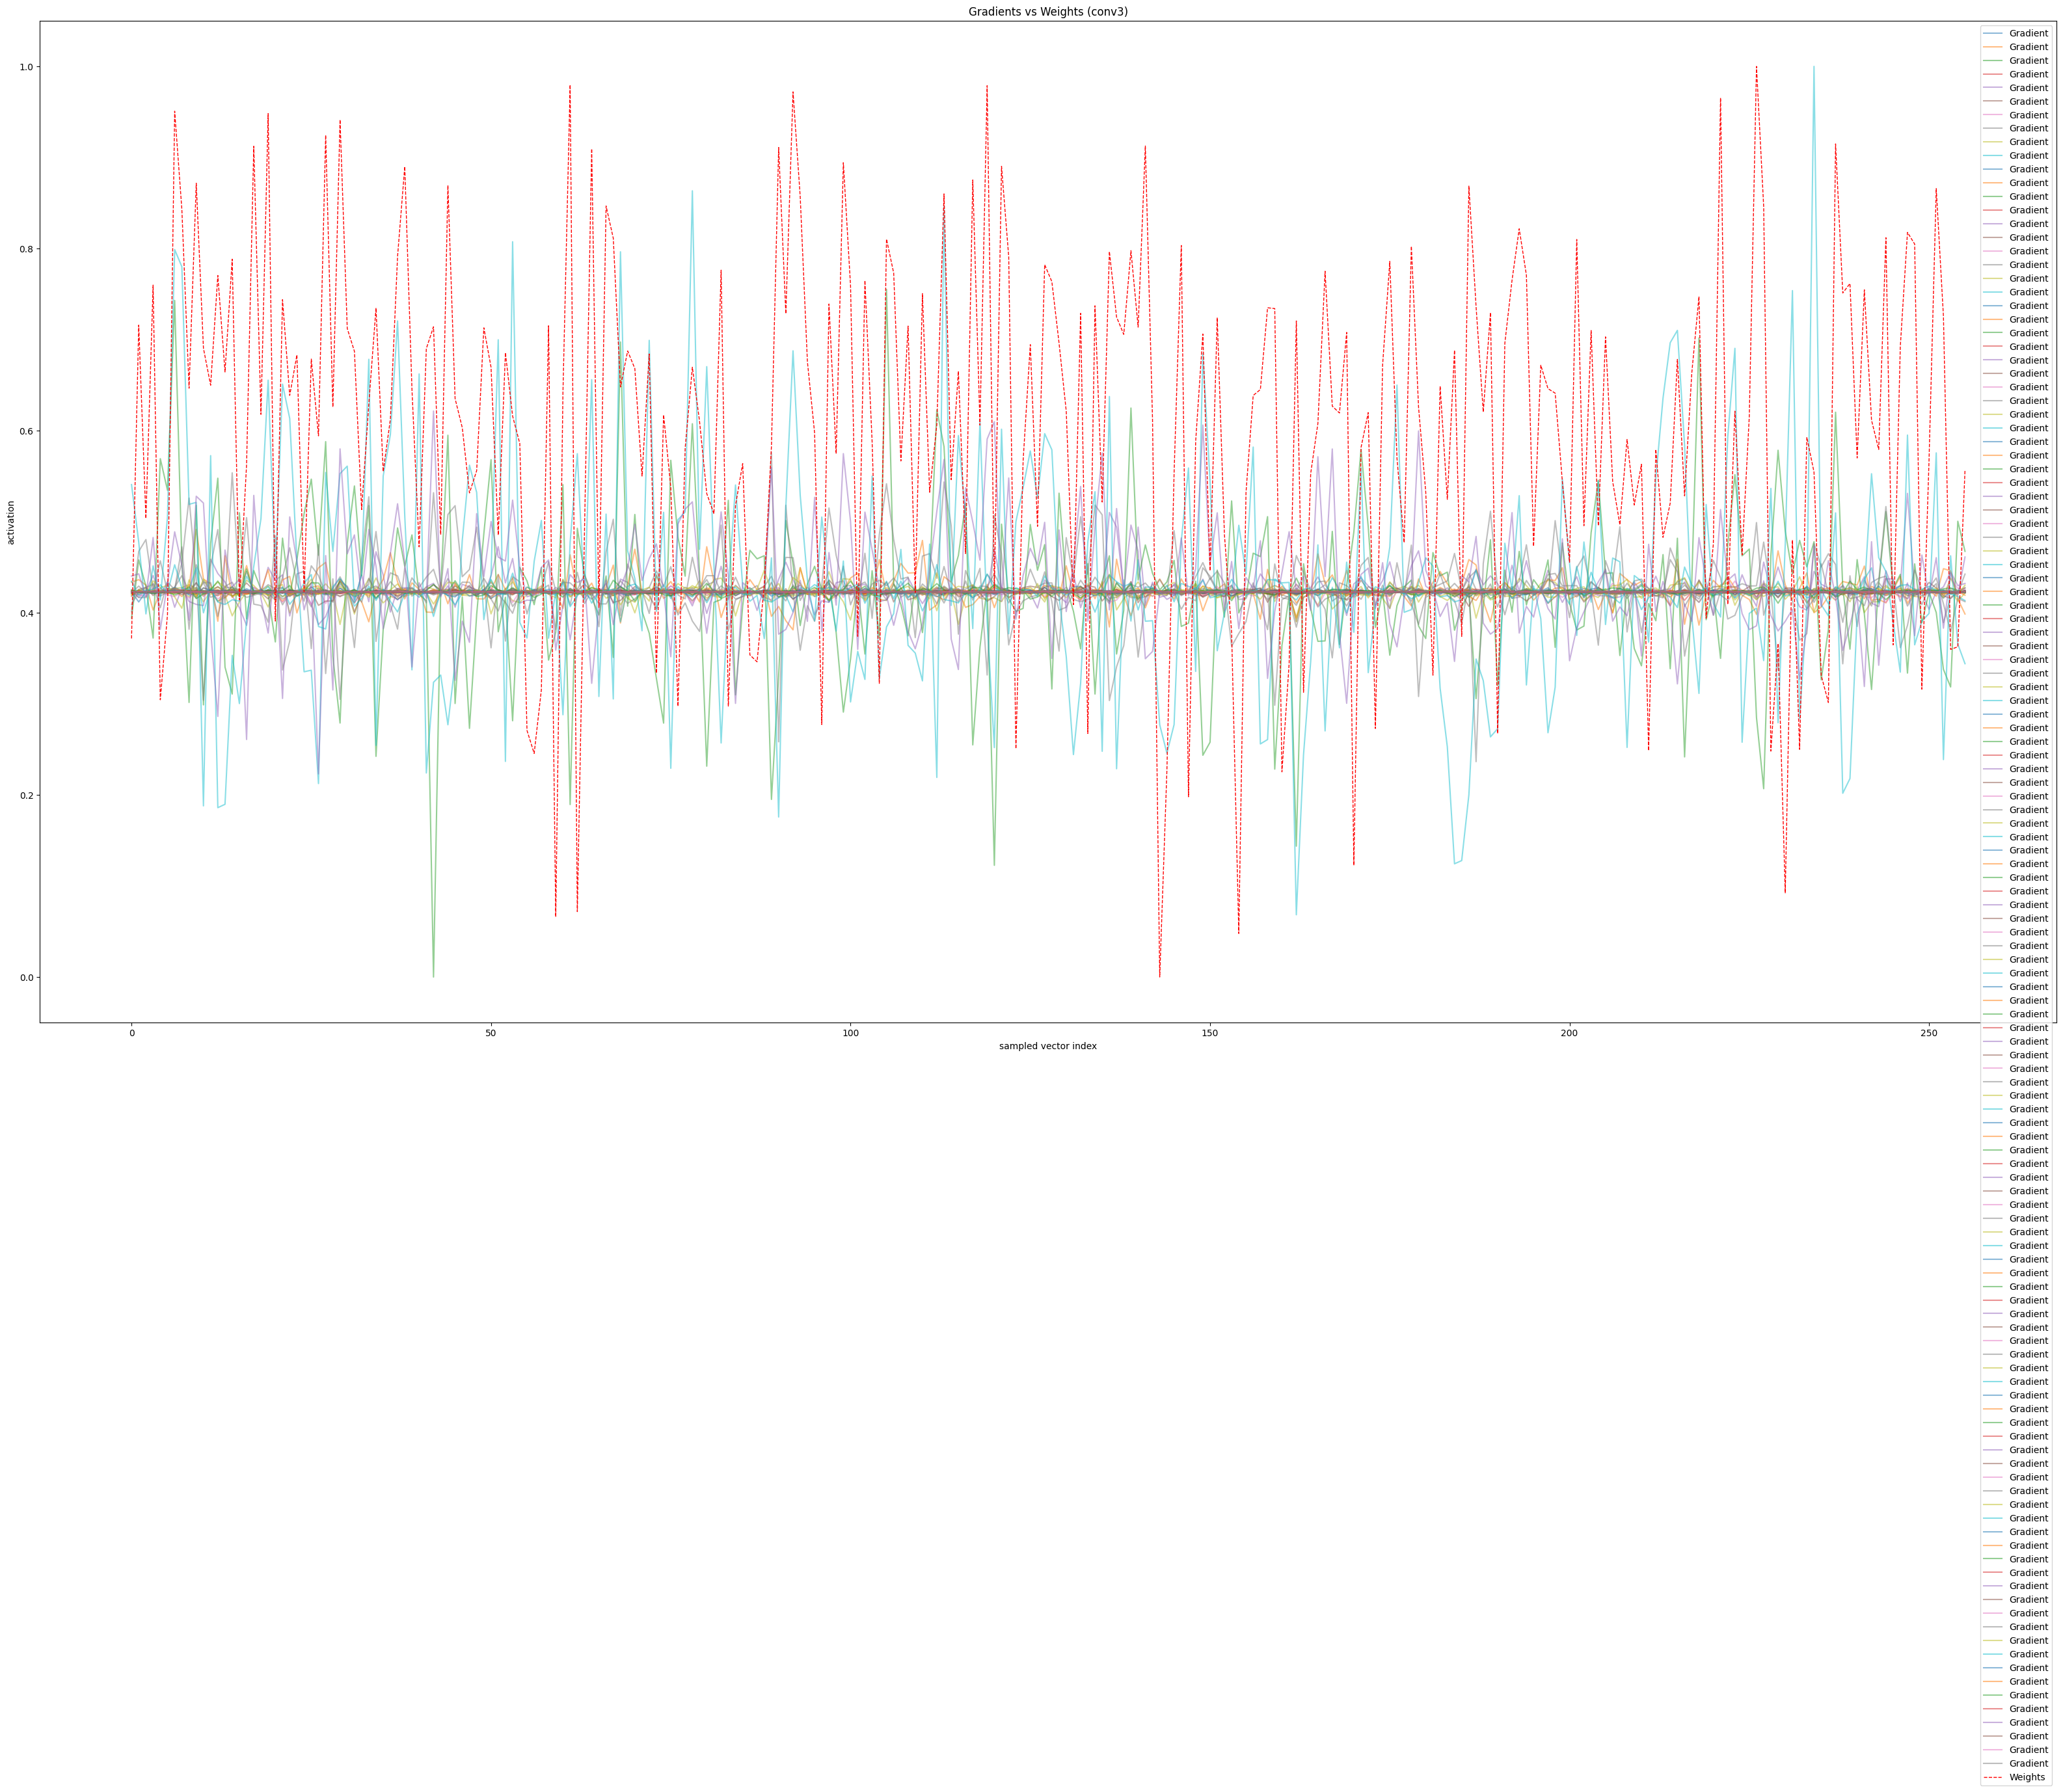

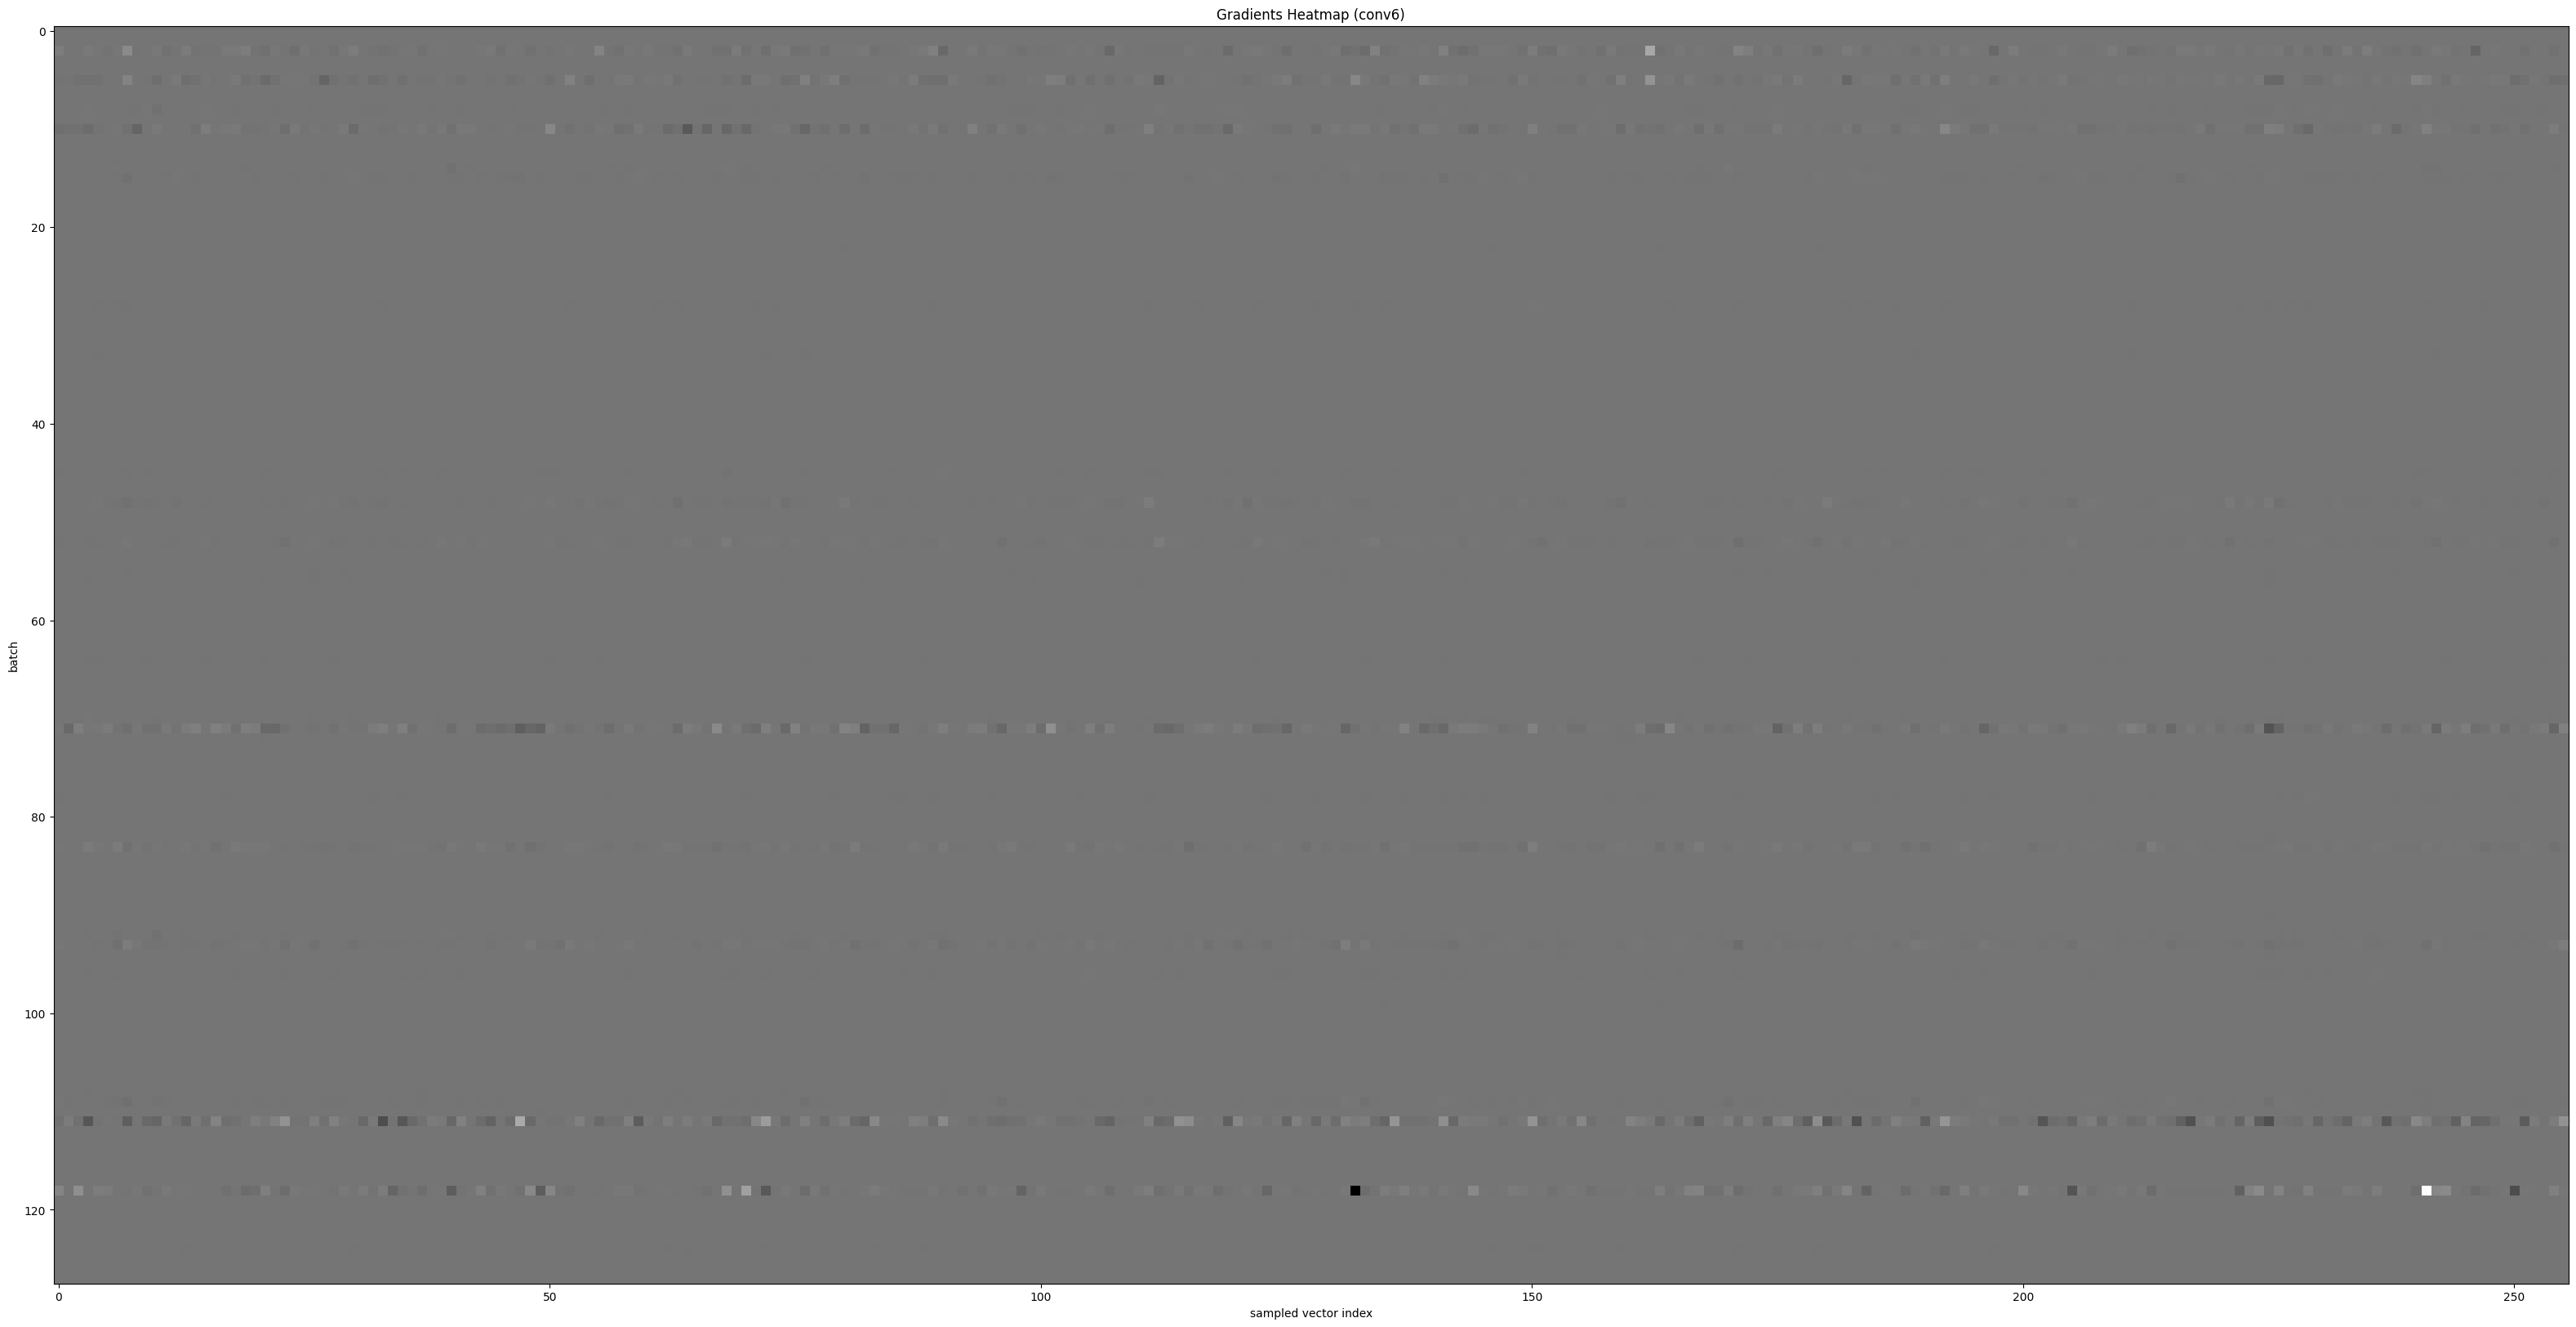

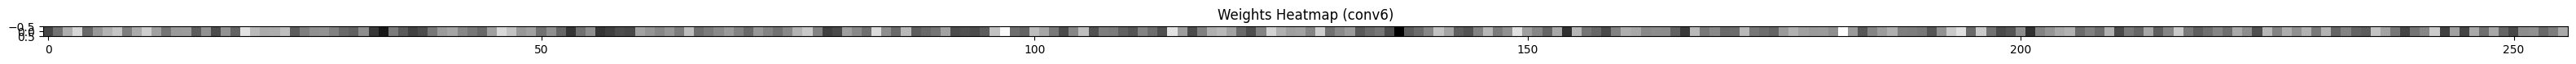

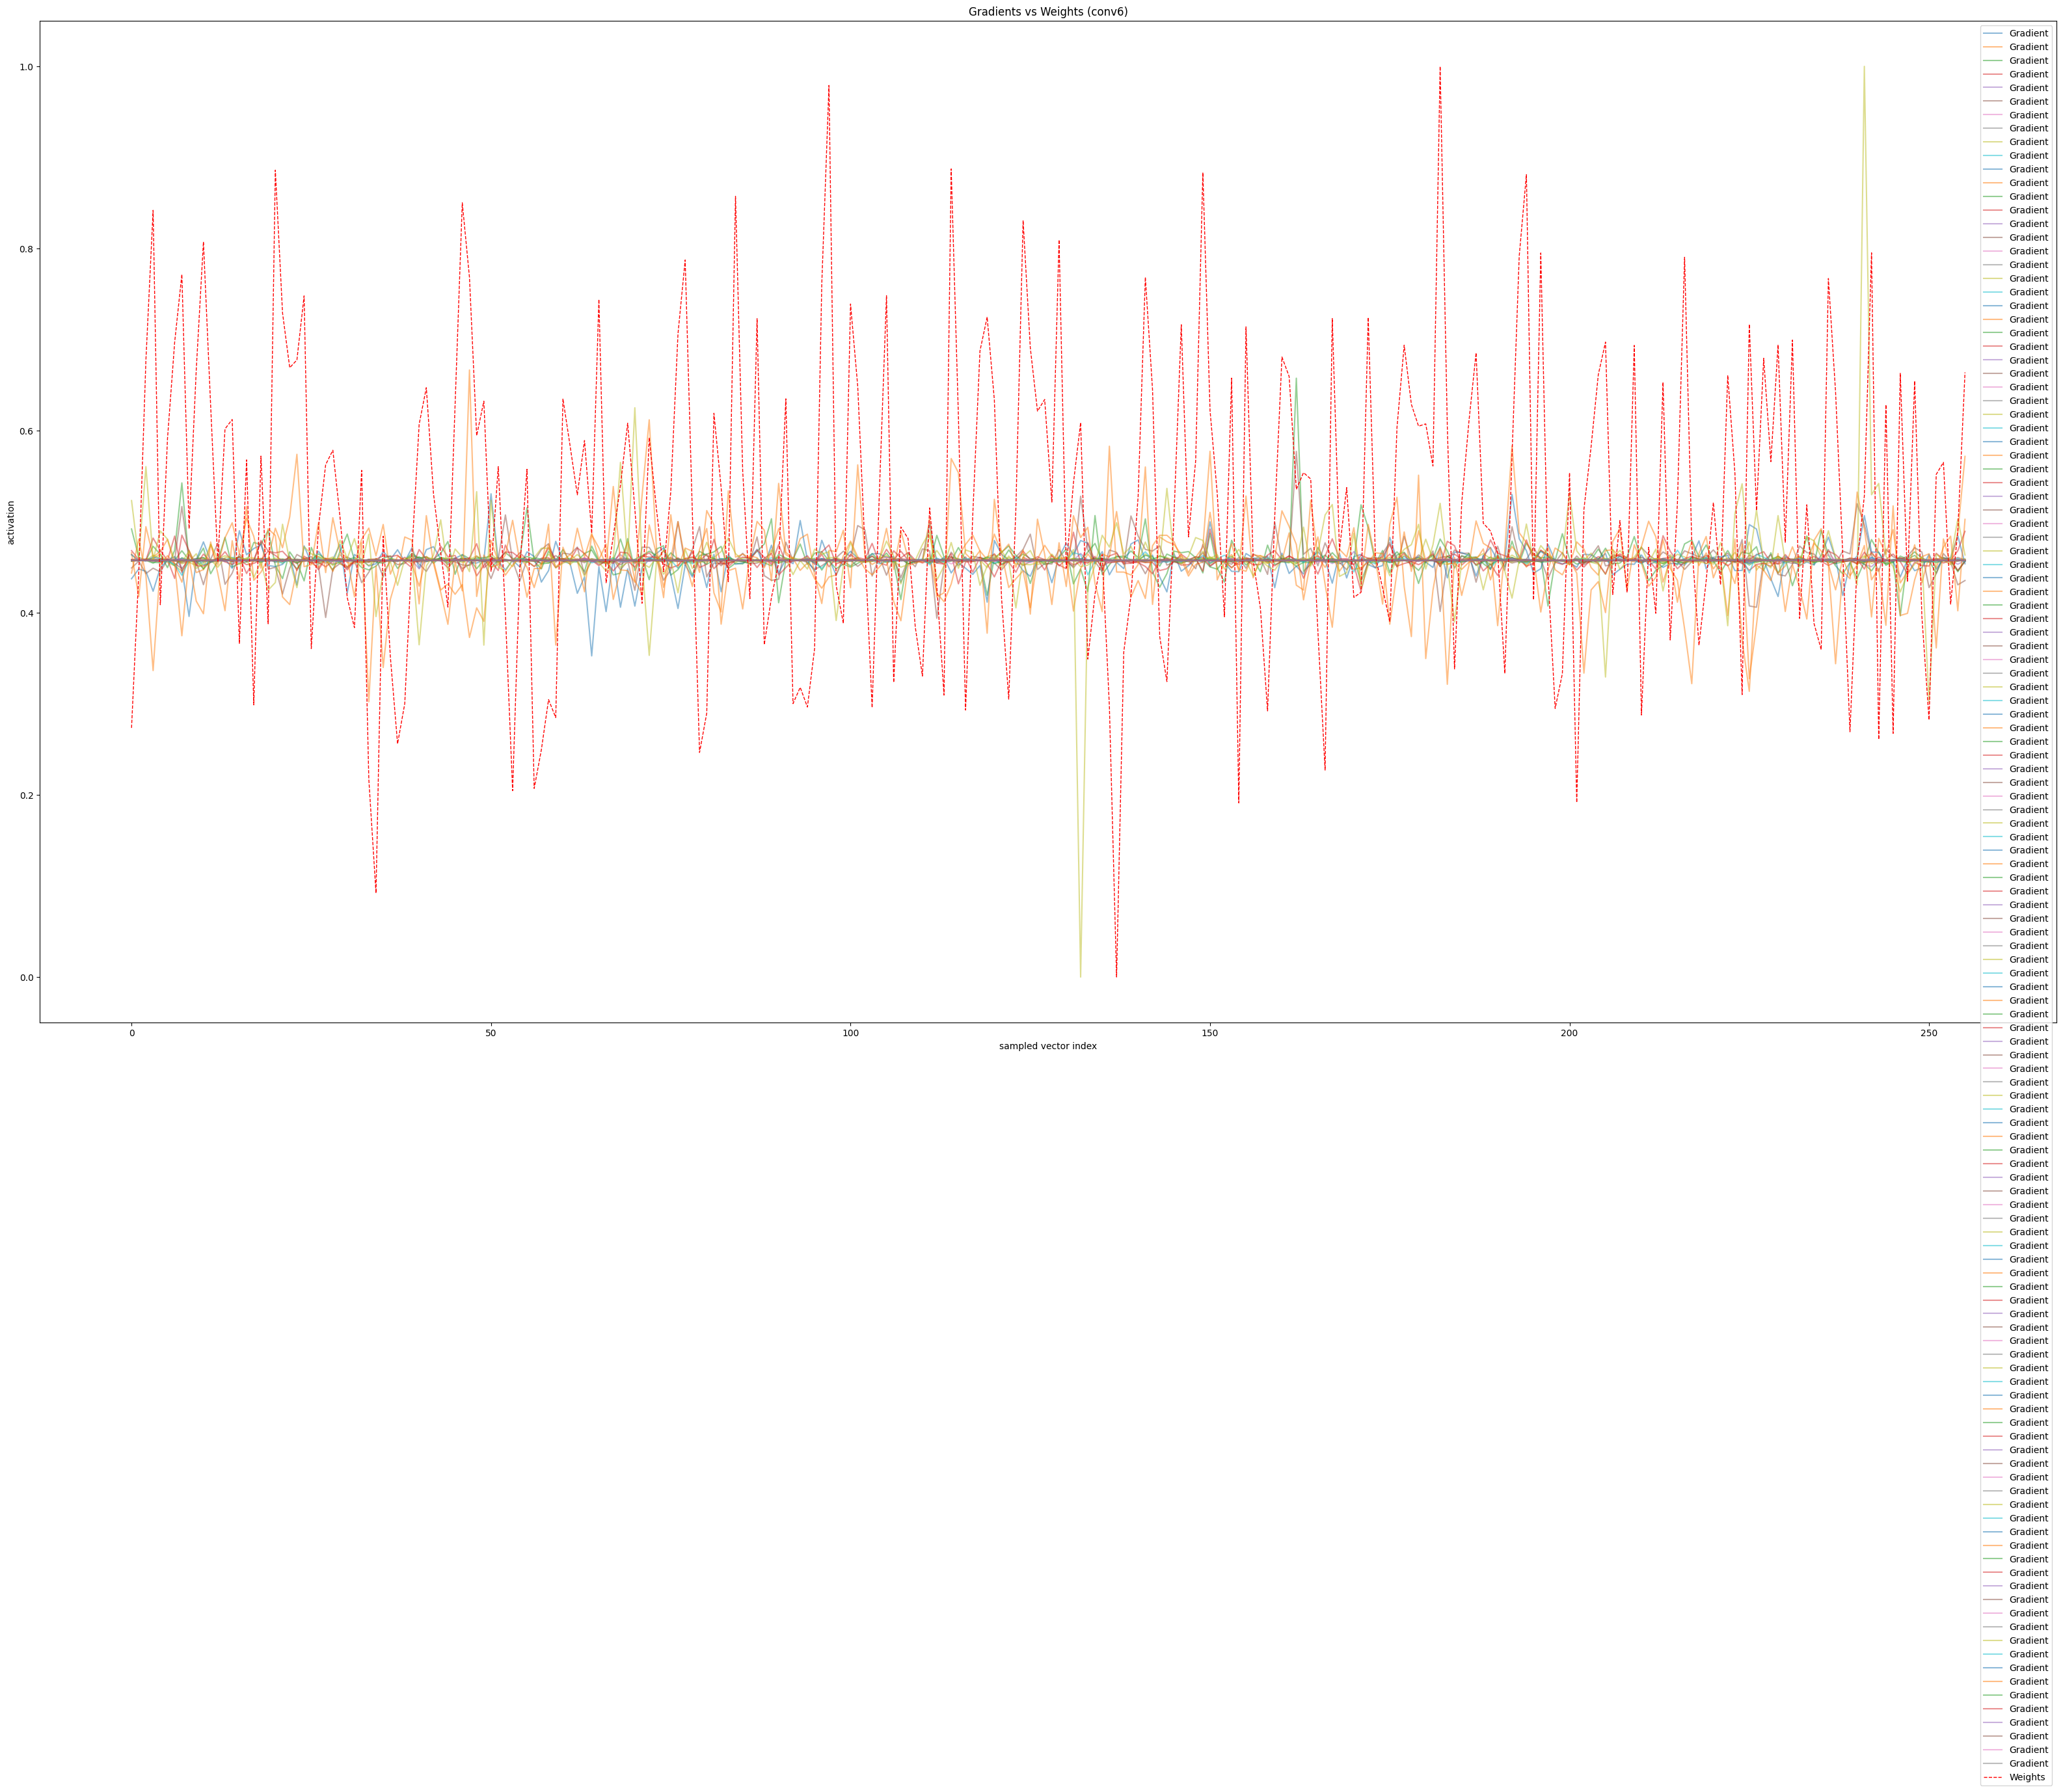

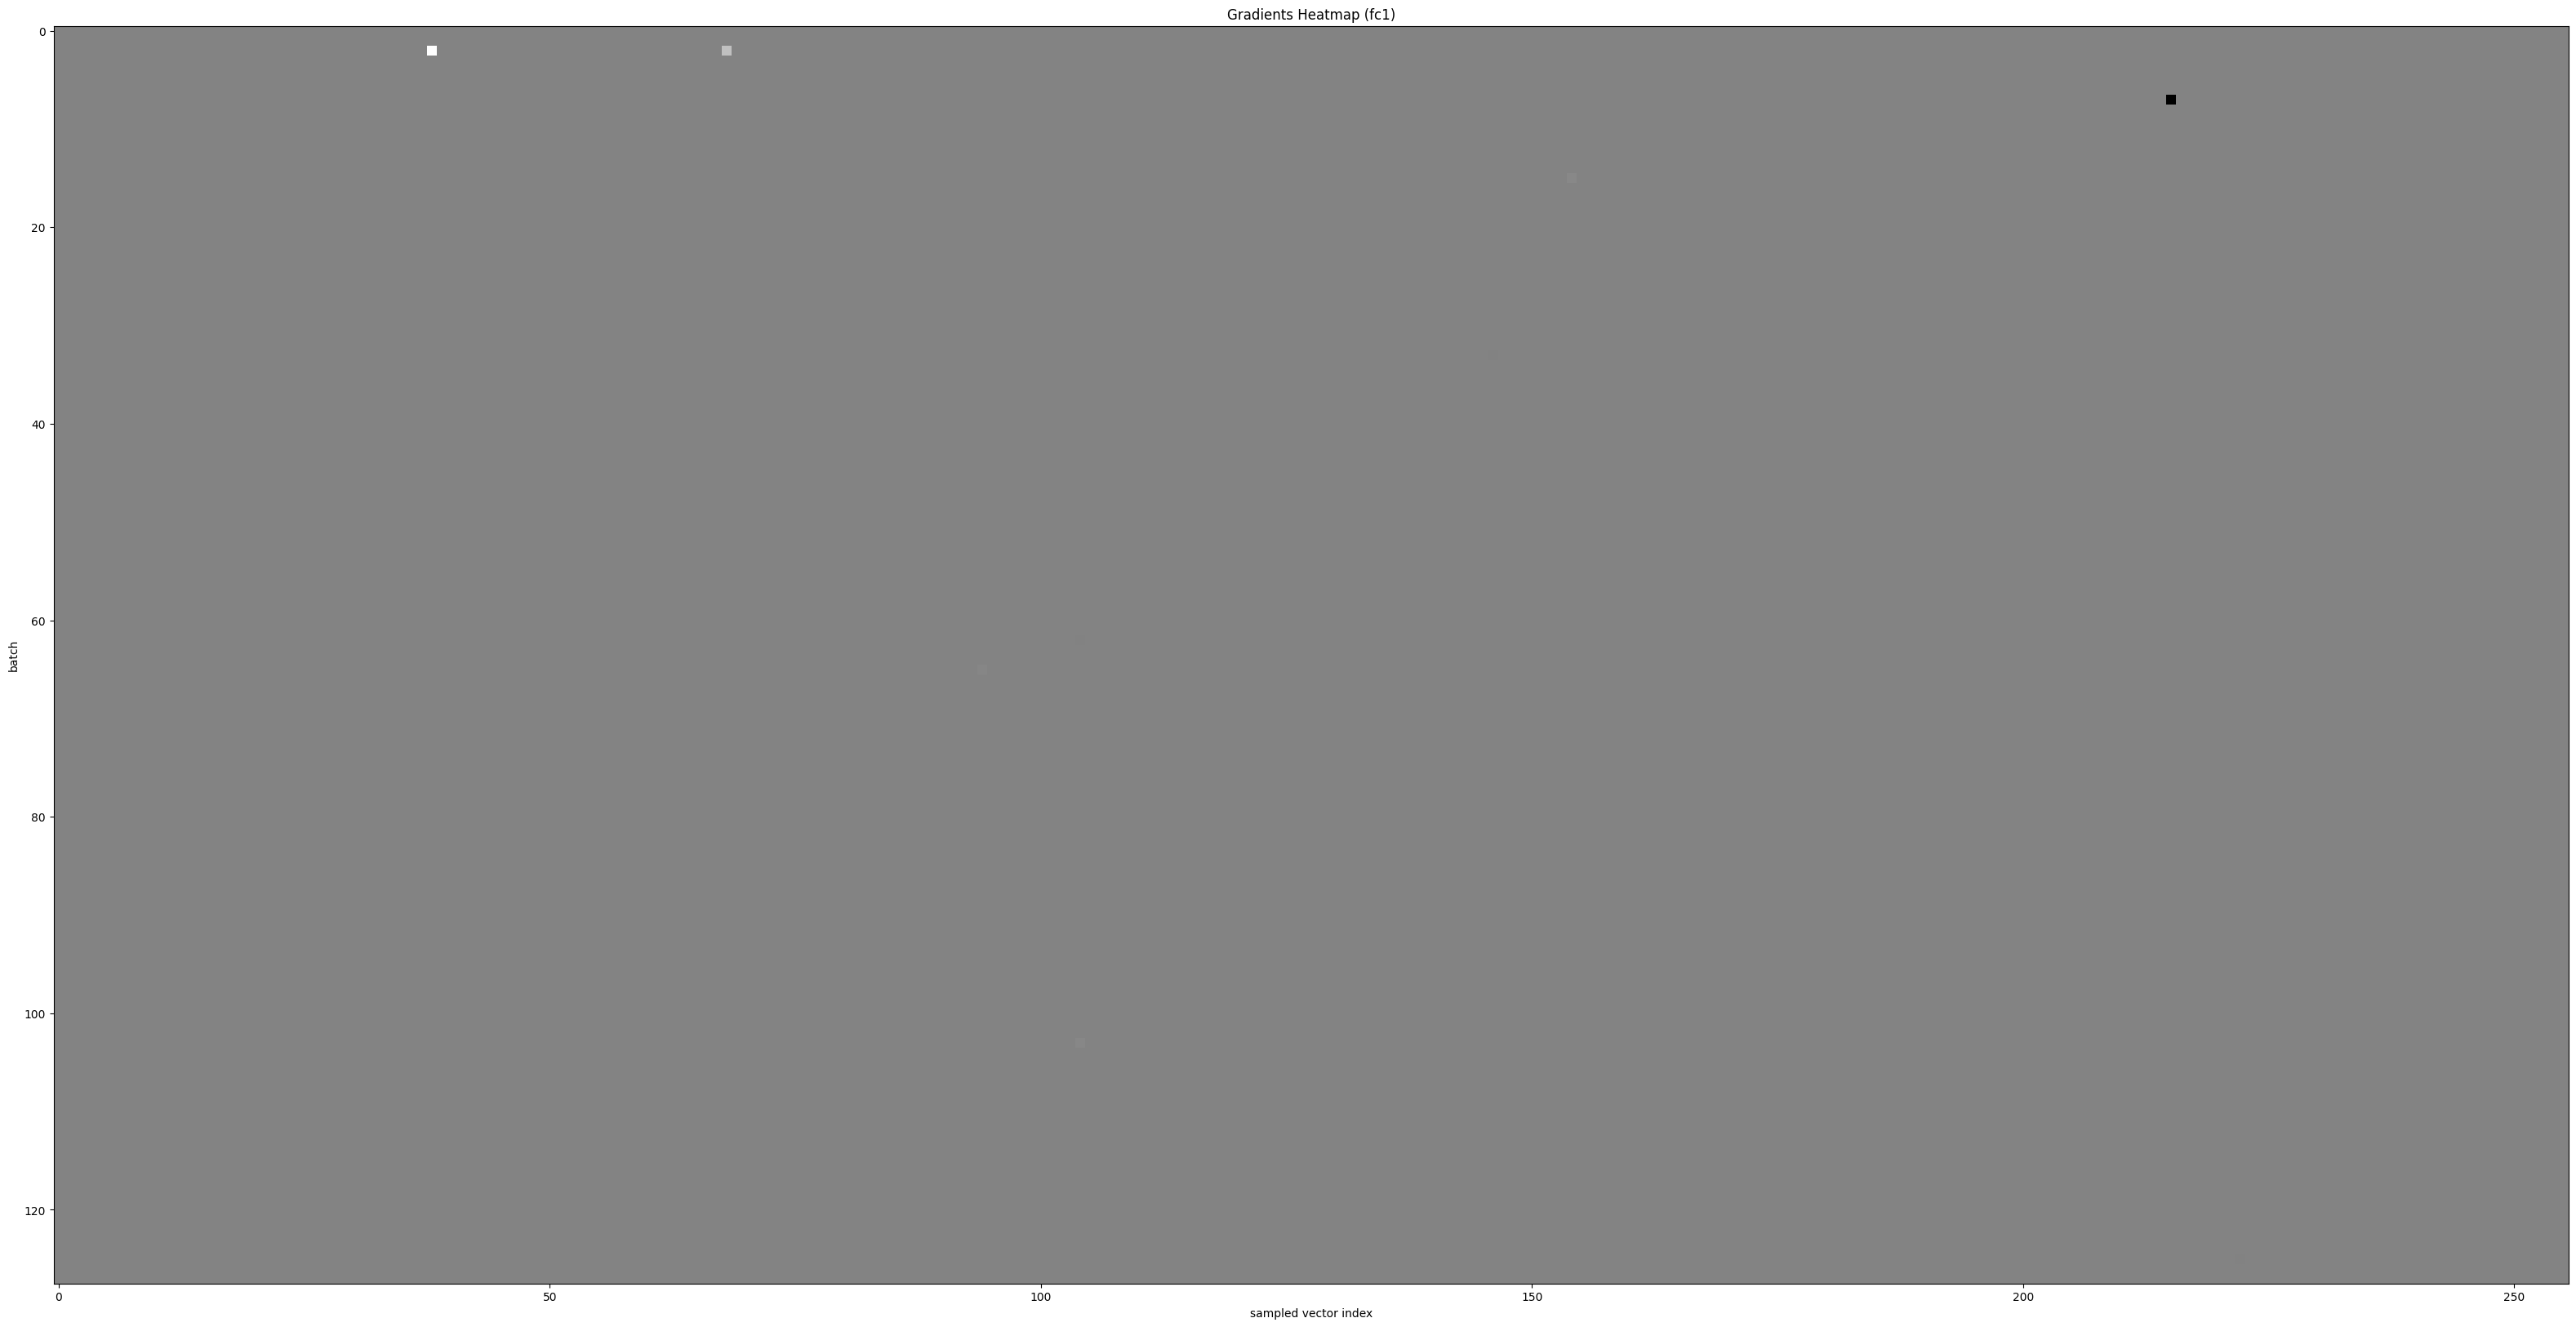

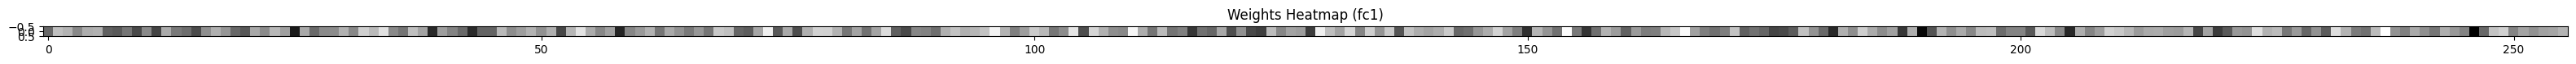

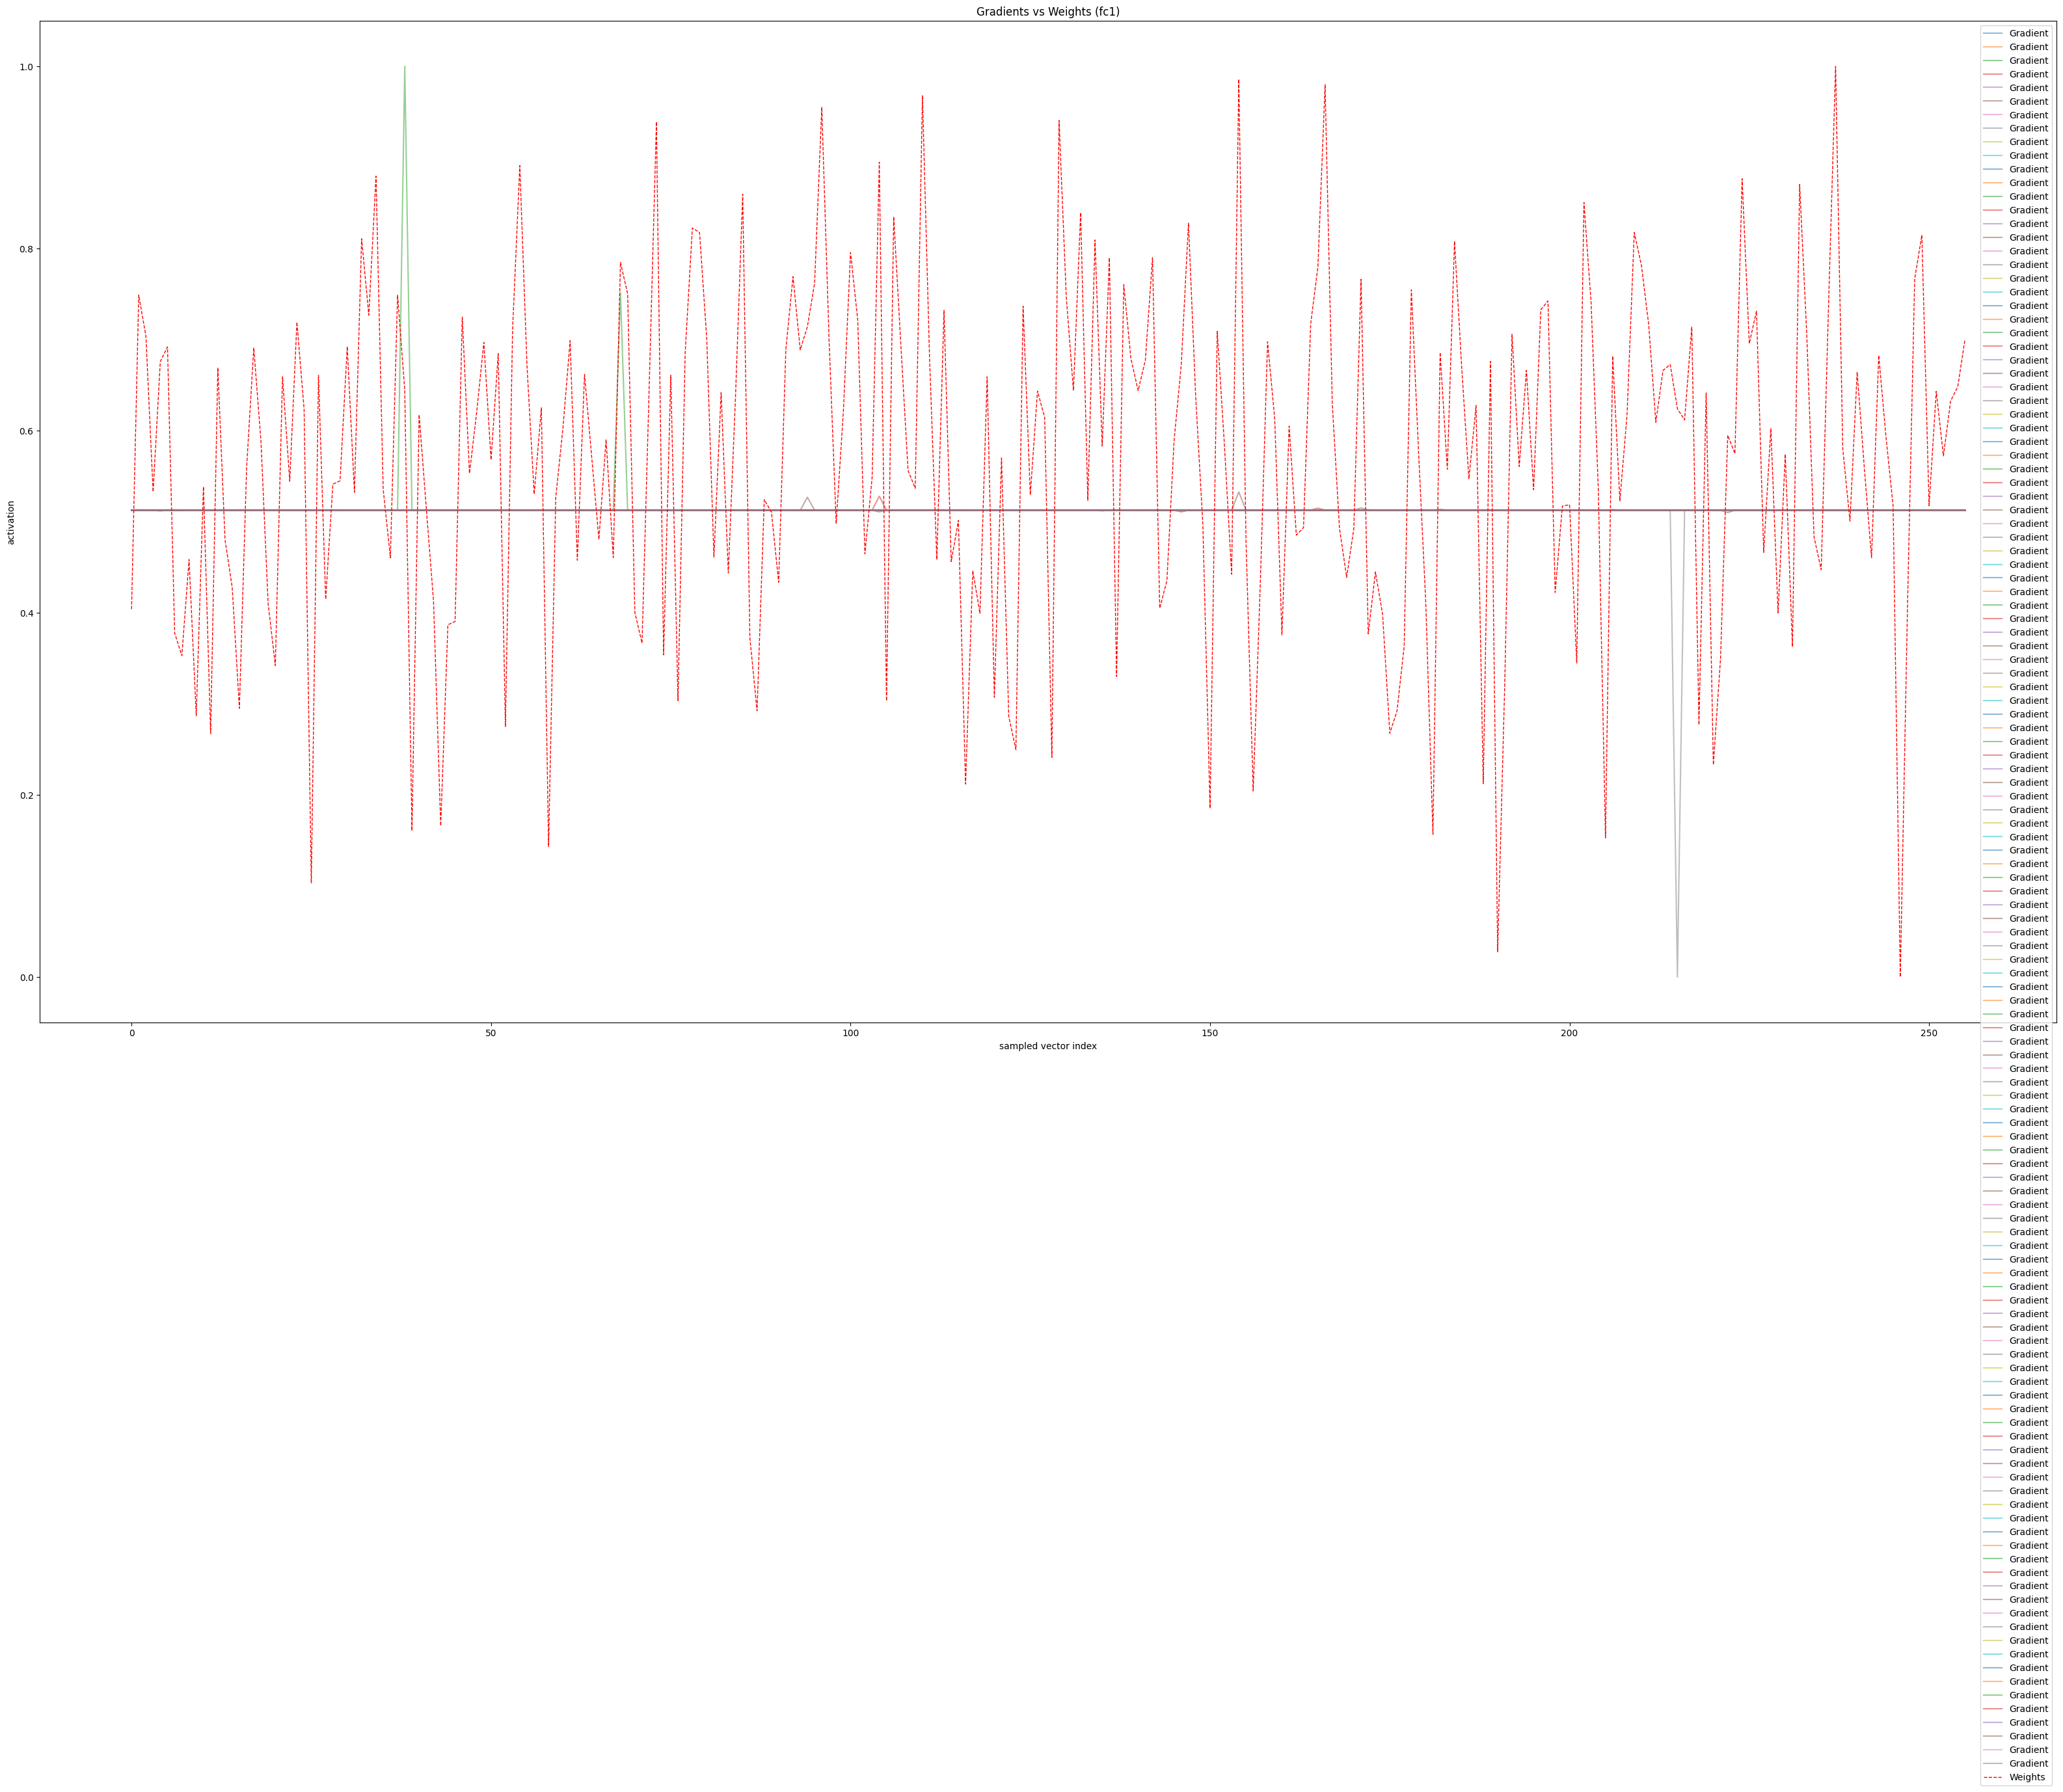

In [123]:
# Visualize gradients
for layer_name in LAYER_NAMES:
  g,w = grads_weights_augs[layer_name]
  visualize_gradients_vs_weights(g, w, layer_name=layer_name, sample_size=NUM_SAMPLE_GRADS)

## Visulalzing Different Version

/tmp/ipython-input-1492638592.py:90: RuntimeWarning:

overflow encountered in exp



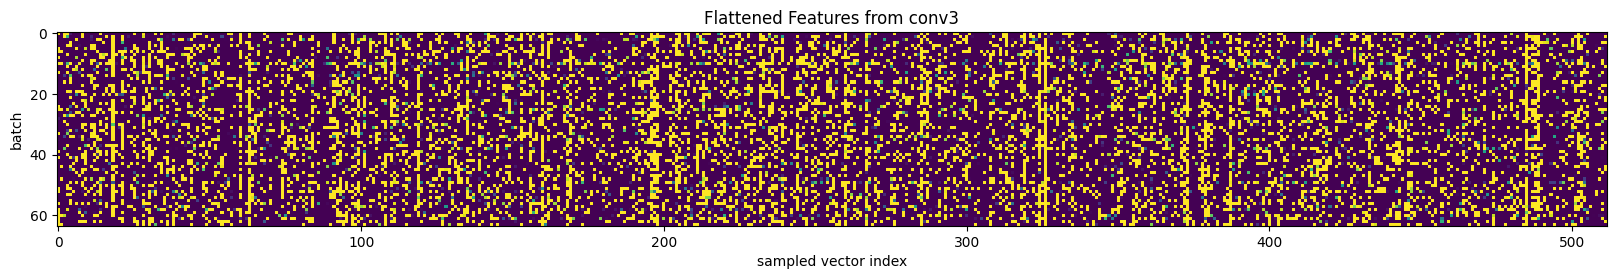

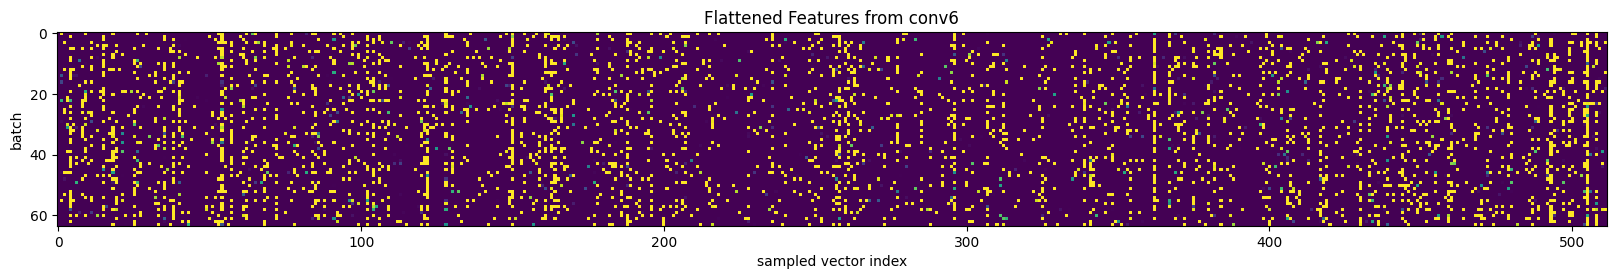

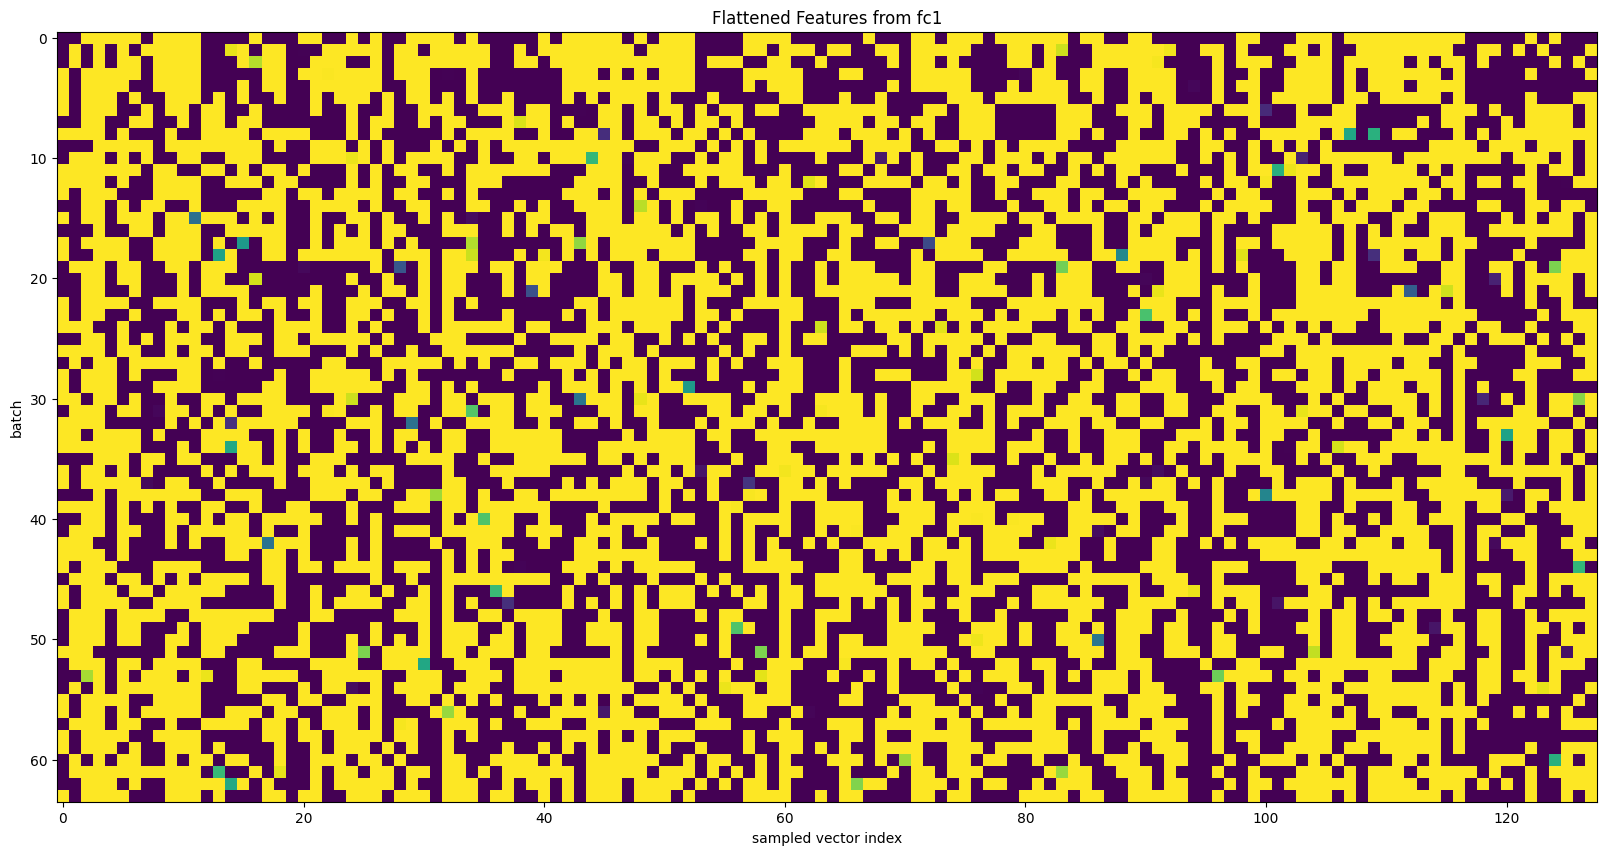

In [124]:
# Visualize intermediate features
for layer_name in LAYER_NAMES:
  visualize_feature_matrix(MODEL, sample_x, layer_name=layer_name)

In [125]:
# Compute  gradients
grads_weights = {}
for layer_name in LAYER_NAMES:
  grads_list, weights = collect_weights_and_grads(MODEL, sample_x, sample_y, layer_name=layer_name)
  grads_weights[layer_name] = (grads_list, weights)

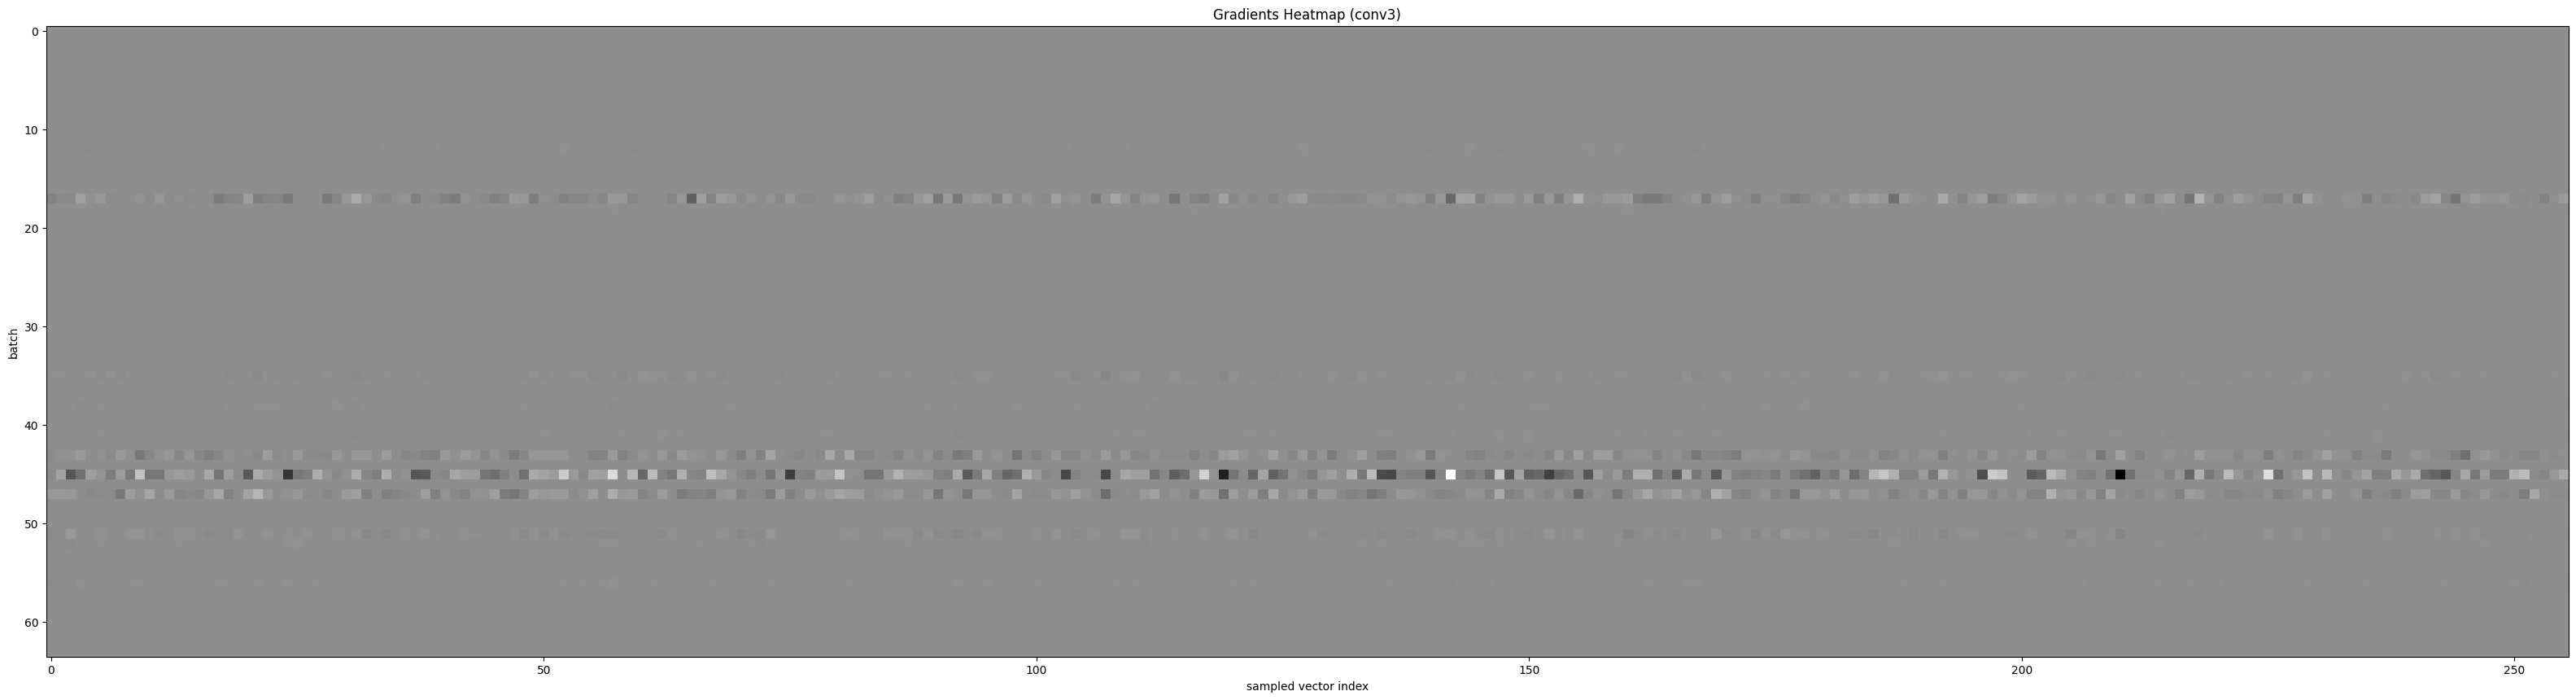

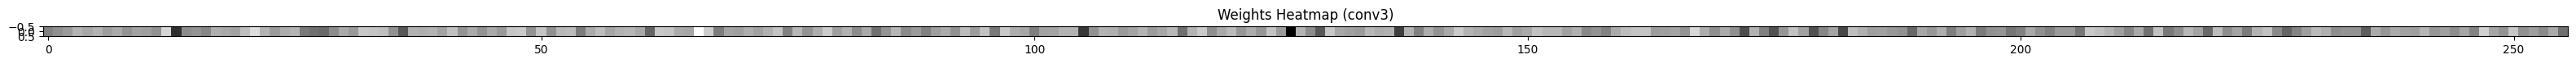

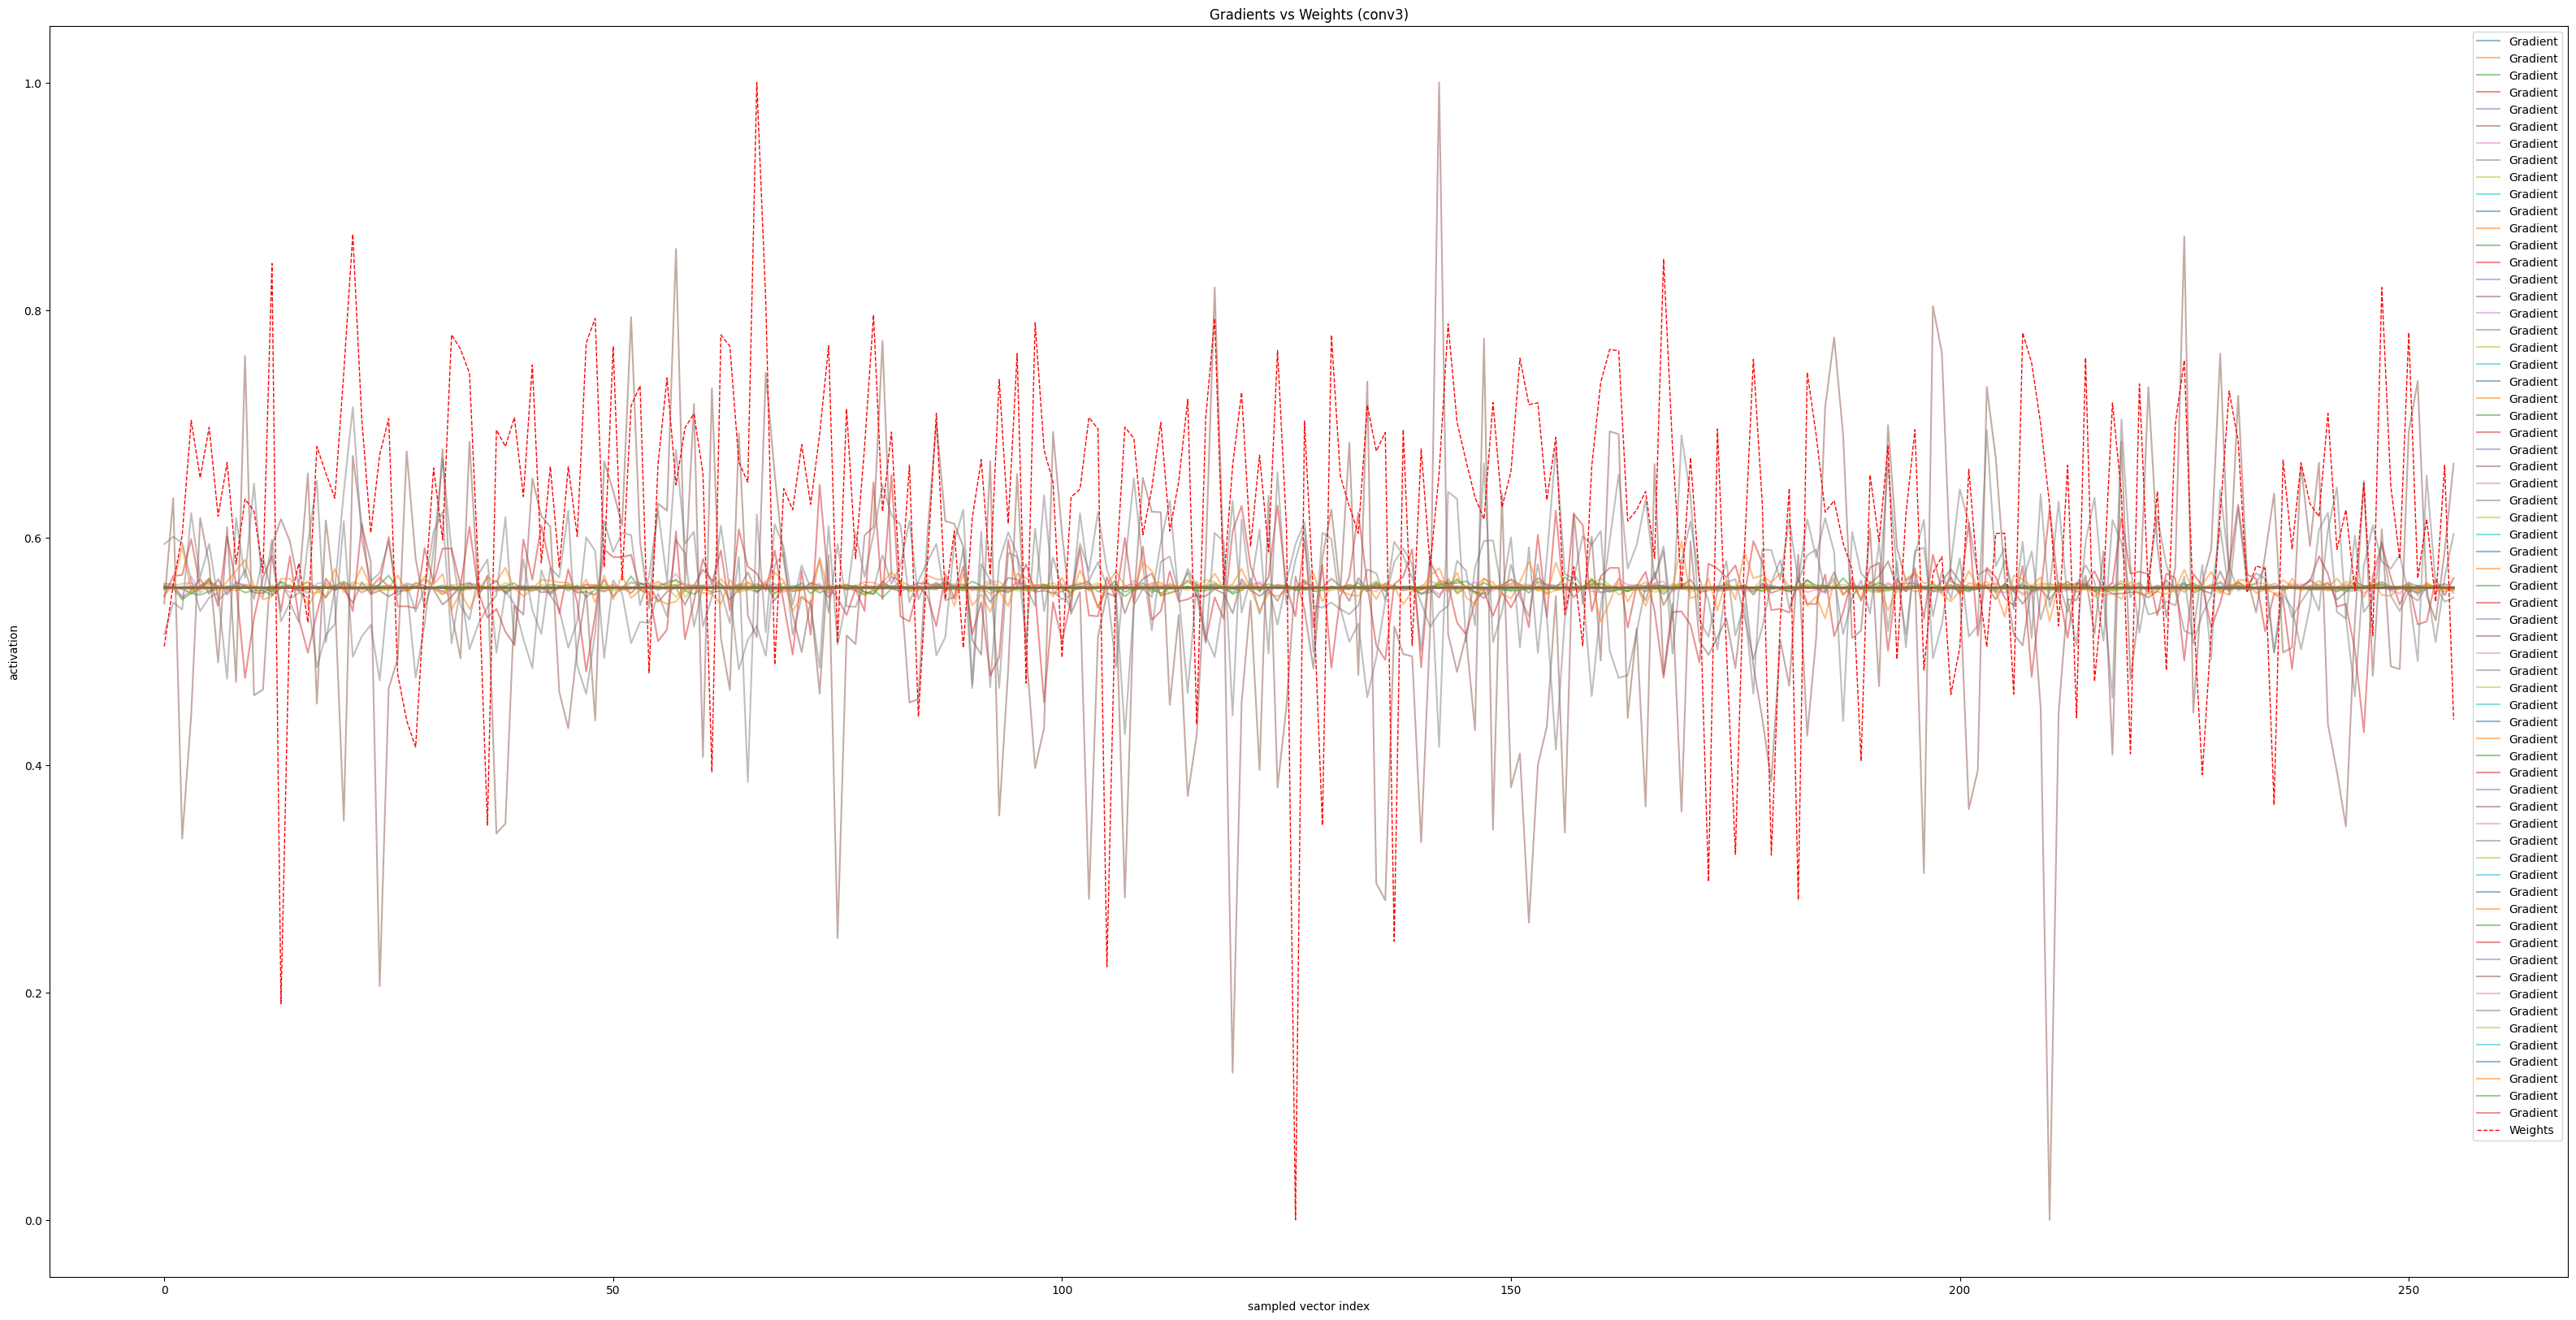

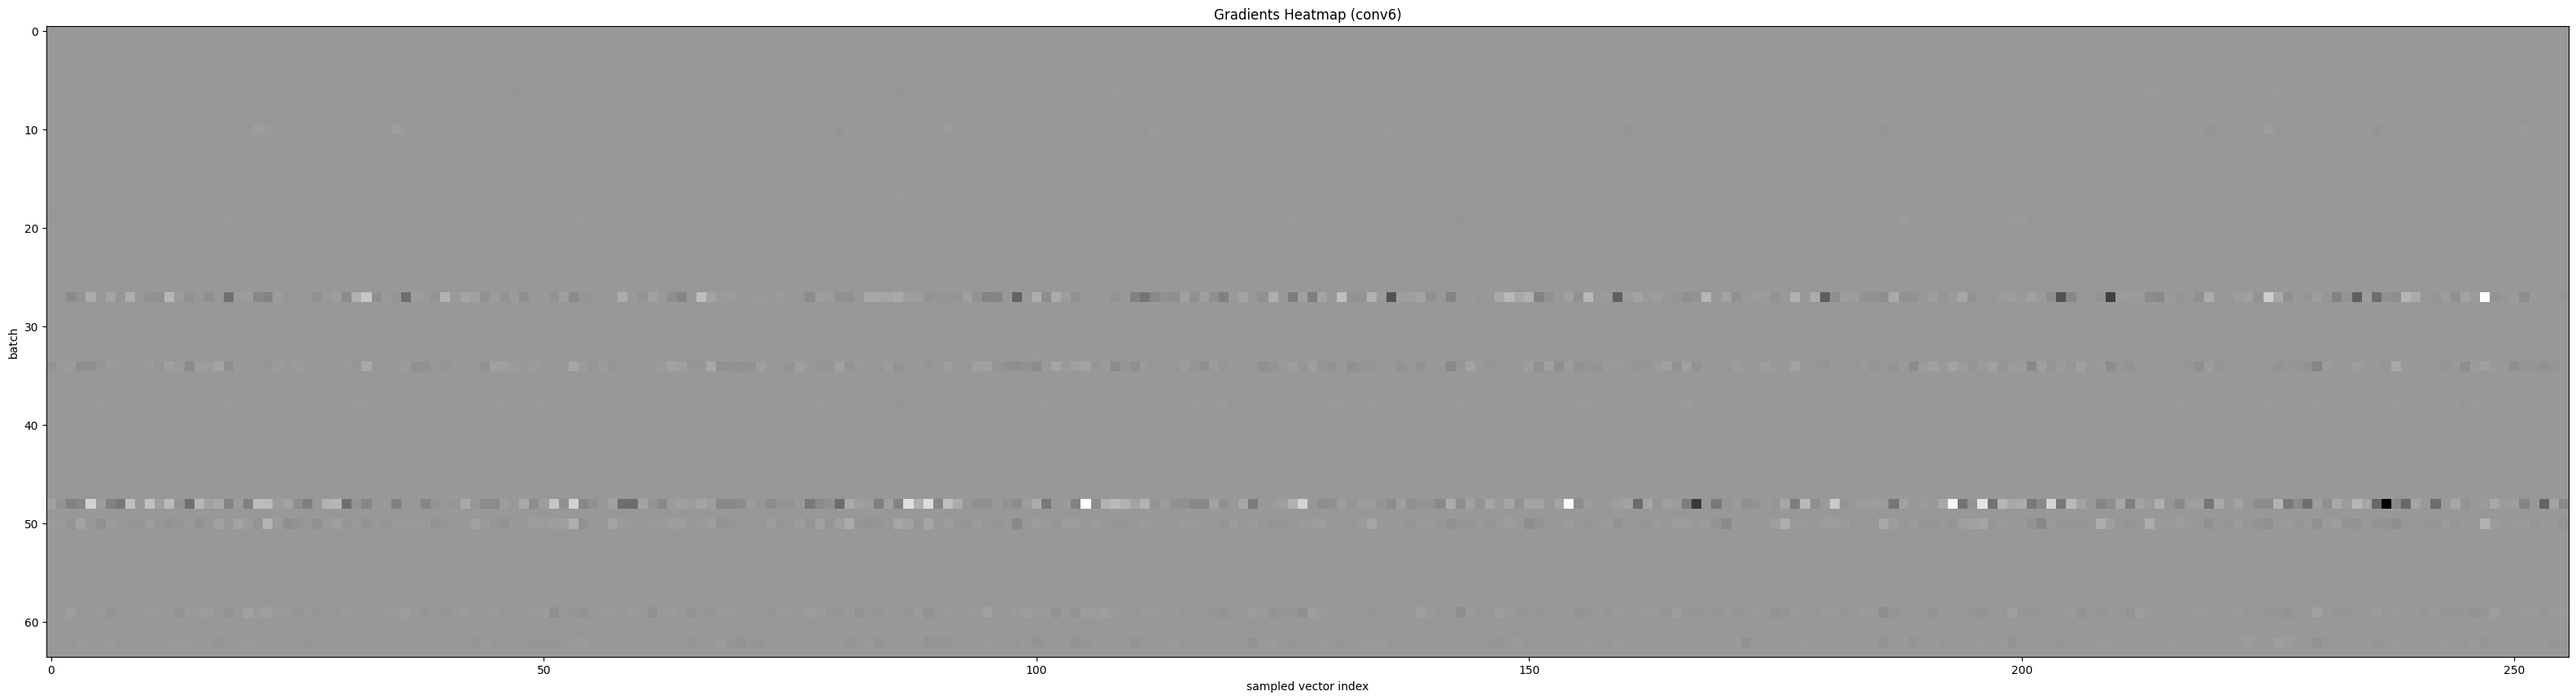

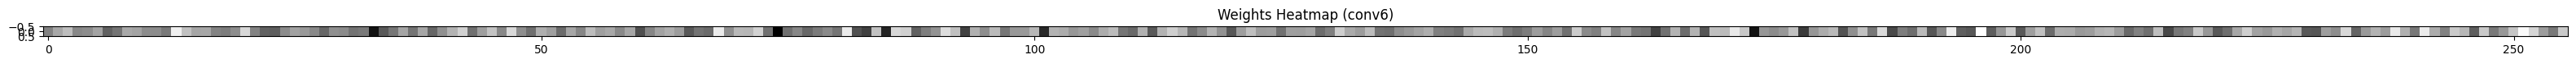

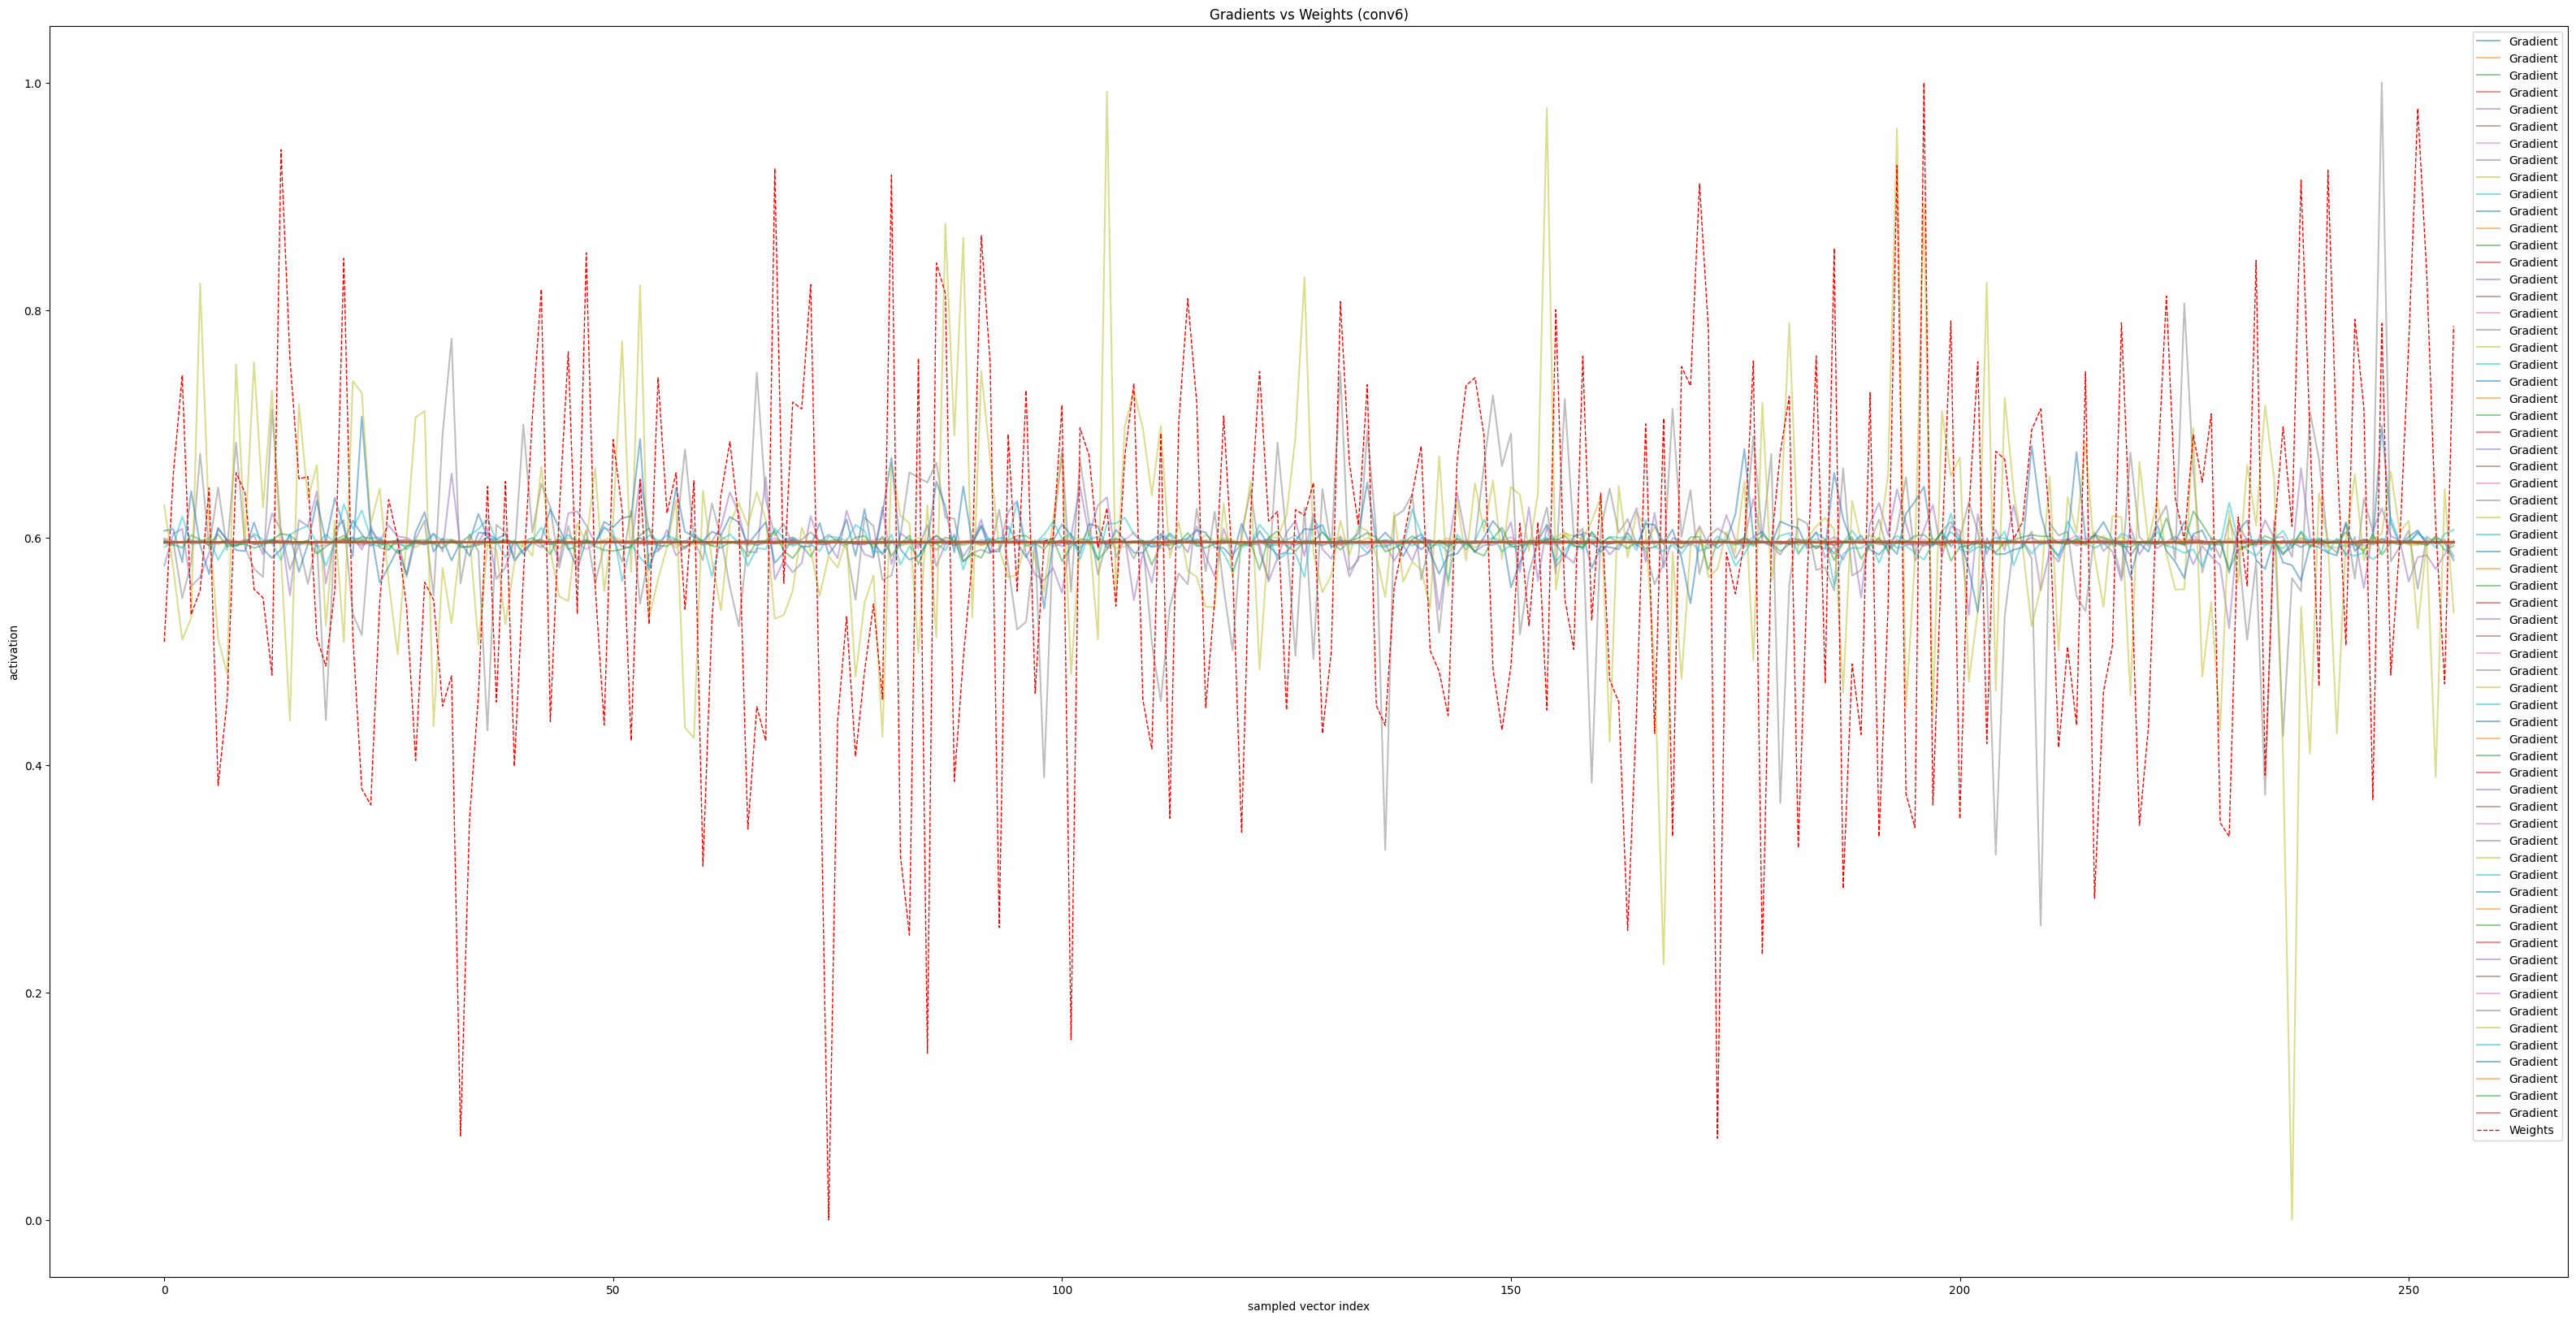

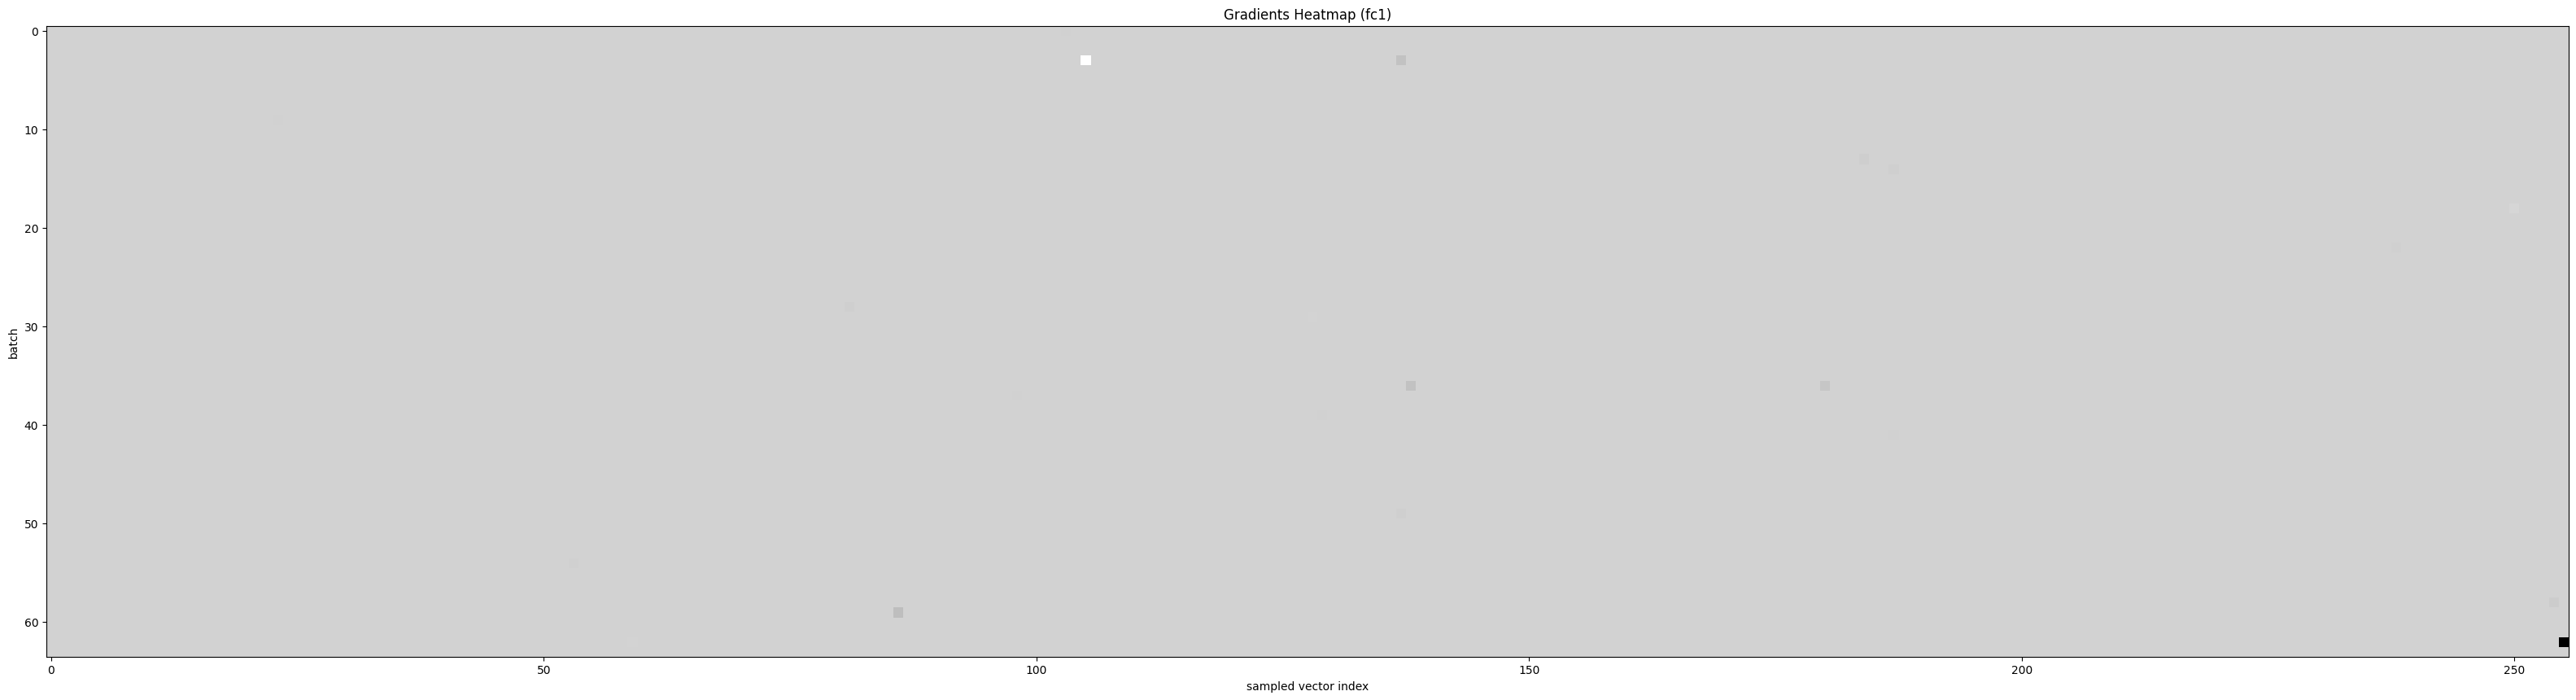

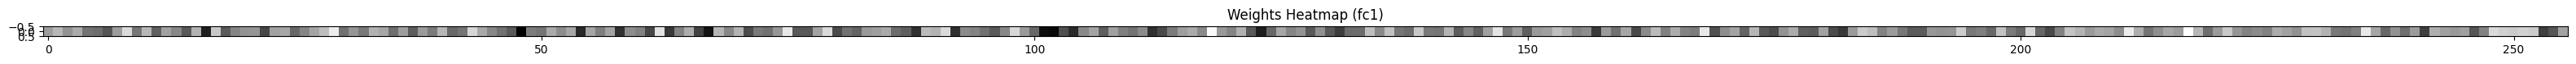

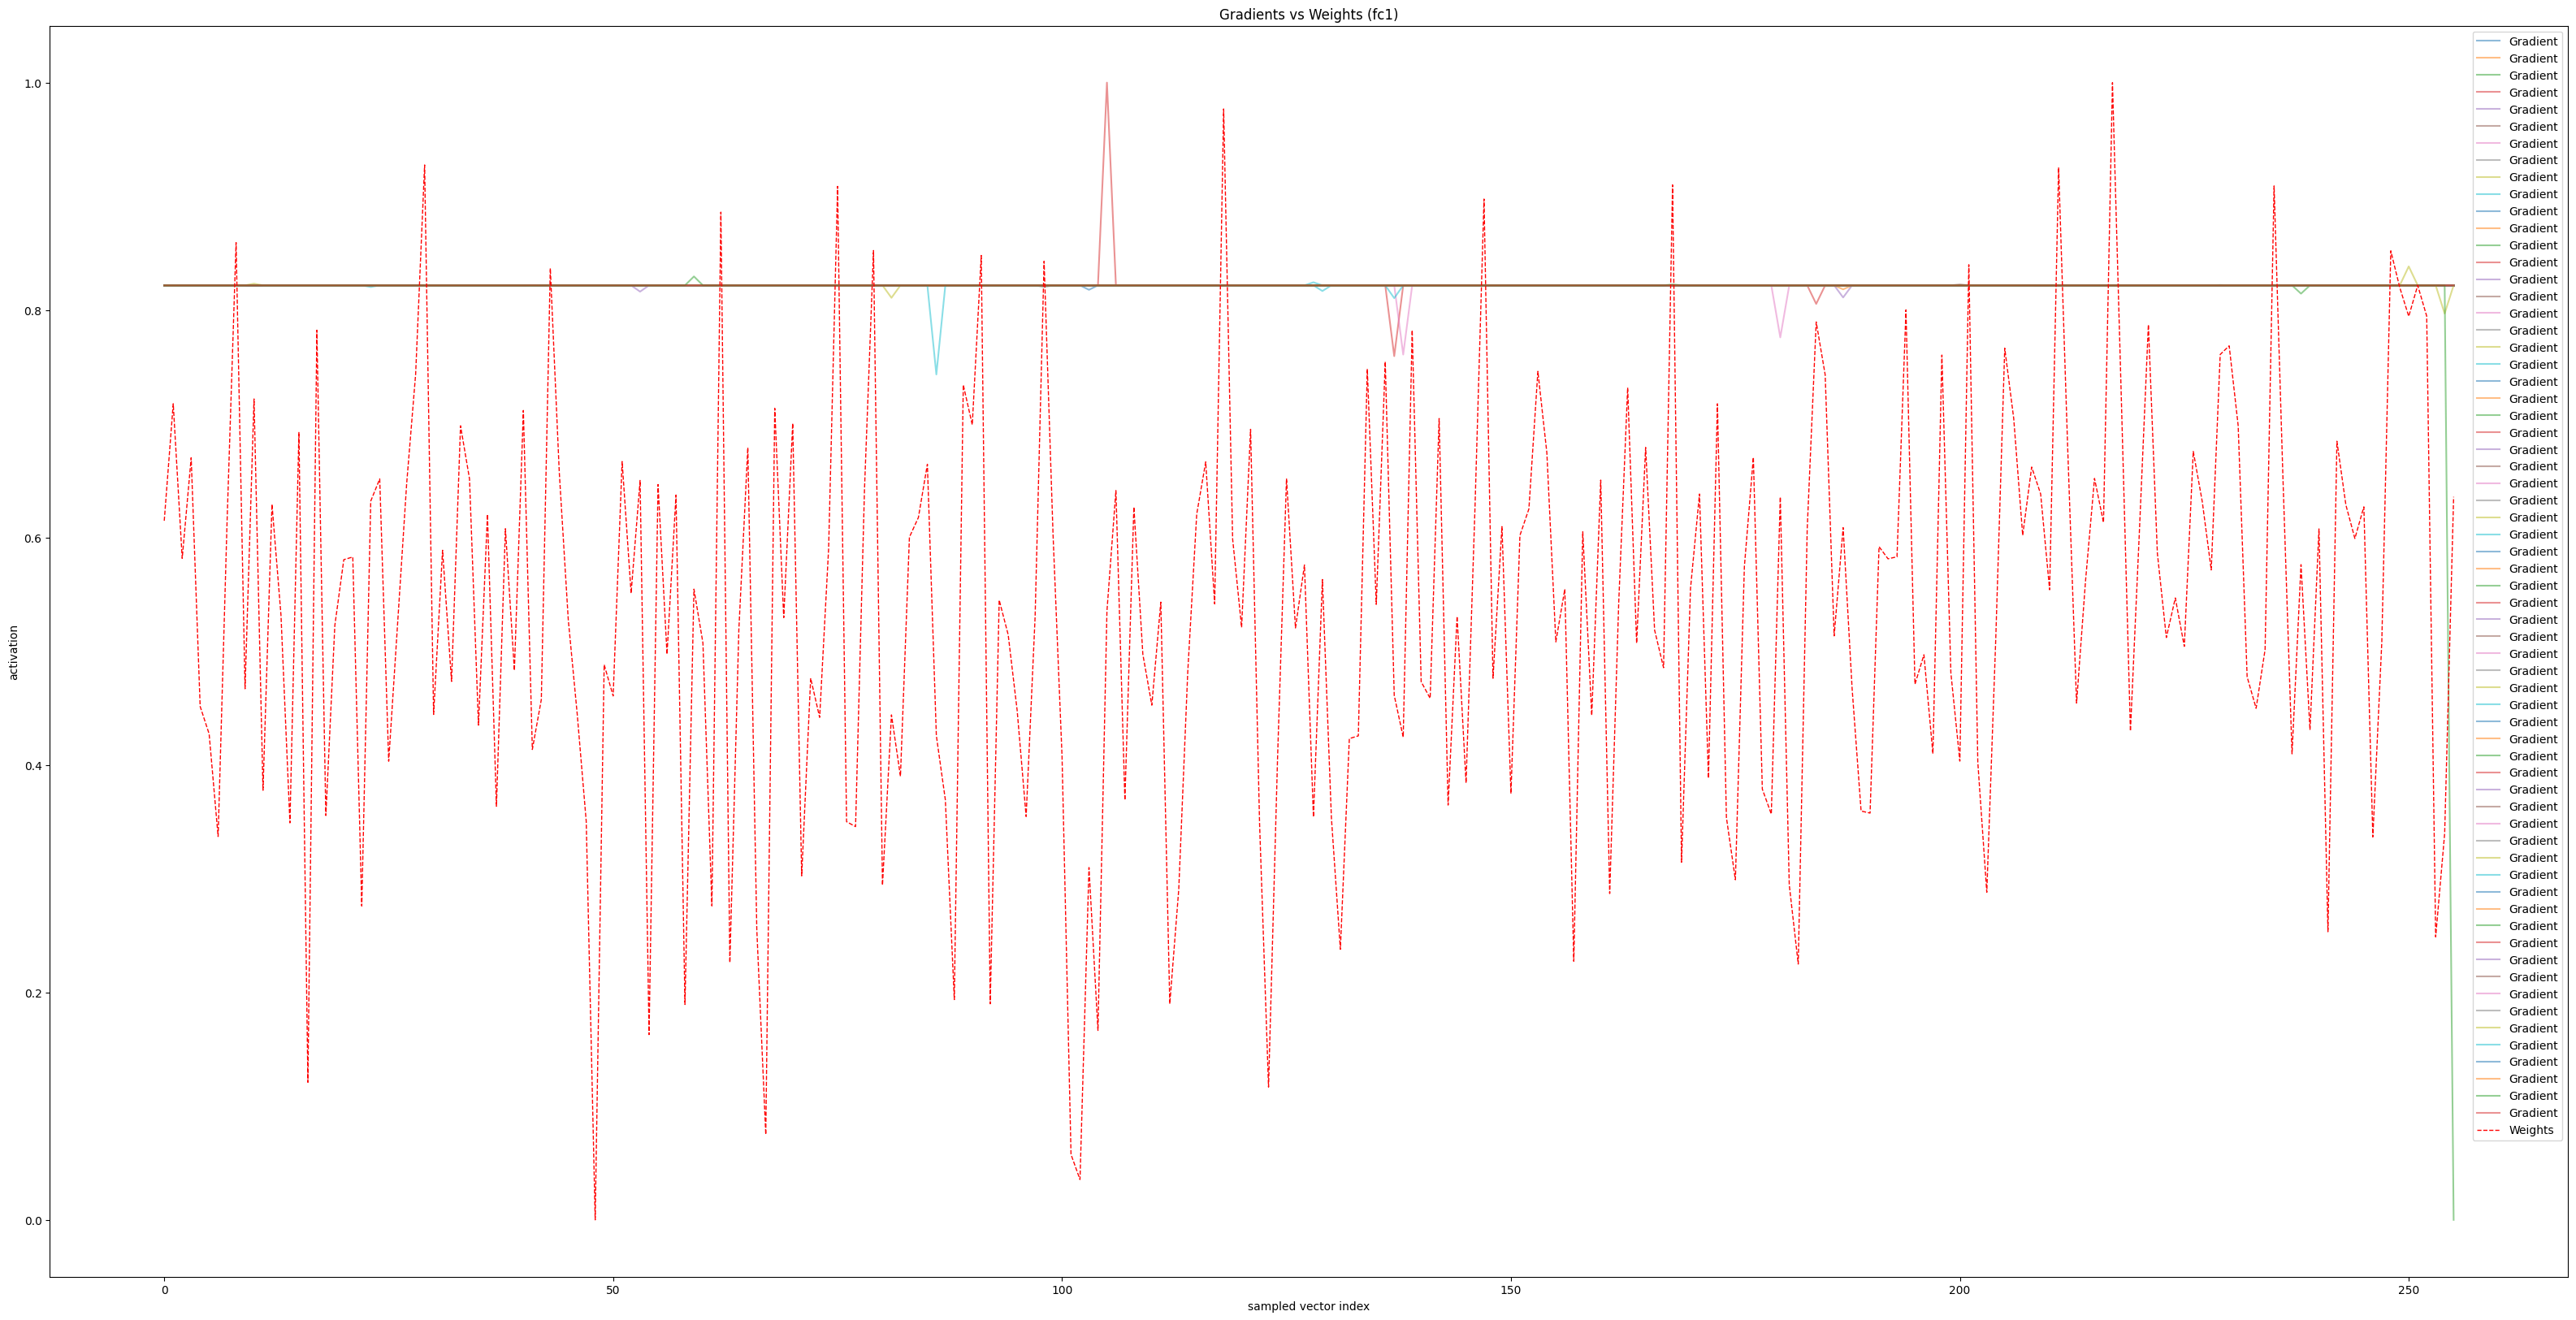

In [126]:
# Visualize gradients
for layer_name in LAYER_NAMES:
  g,w = grads_weights[layer_name]
  visualize_gradients_vs_weights(g, w, layer_name=layer_name, sample_size=NUM_SAMPLE_GRADS)